## 1️⃣ Importar librerías y definir funciones auxiliares
Importamos las librerías necesarias y definimos funciones para cargar datos, aplicar time shift, detectar plateaus y realizar fits.

In [16]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

# Función para cargar datos ROOT (adaptar a tu estructura de árbol)
def cargar_datos_root(filepath):
    file = uproot.open(filepath)
    peak_data = file["peak"].arrays(library="np")
    temp_data = file["temp"].arrays(library="np")
    press_data = file["press"].arrays(library="np")
    return peak_data, temp_data, press_data

# Función para aplicar time shift a un array de timestamps
def aplicar_time_shift(times, shift_horas):
    return np.array([t + datetime.timedelta(hours=shift_horas) for t in times])

# Función para filtrar y detectar plateaus (provisional, editable)
def seleccionar_plateaus(tiempos, intervalos):
    # intervalos: lista de tuplas (t_ini, t_fin)
    masks = [(tiempos >= t_ini) & (tiempos <= t_fin) for t_ini, t_fin in intervalos]
    return masks

# Función para ajustar (fit) linealmente cada plateau
def fit_plateau(x, y):
    mask = ~np.isnan(x) & ~np.isnan(y)
    if np.sum(mask) < 2:
        return np.nan, np.nan
    slope, intercept, r_value, p_value, std_err = stats.linregress(x[mask], y[mask])
    return slope, std_err


# Análisis FBG: PEEK-1 (450μm) – 4 días (25-09-24, 26-09-24, 30-09-24, 01-10-24)

Este notebook analiza los archivos de la fibra PEEK-1 (450μm) correspondientes a las fechas indicadas. El objetivo es detectar plateaus, realizar fits y analizar la repetibilidad de las sensibilidades. El flujo sigue el estilo del notebook de DW-3 (11-02-26), pero está simplificado para depuración y comparación rápida.

**Pasos principales:**
1. Importar librerías y definir funciones auxiliares
2. Cargar y visualizar datos de los cuatro archivos
3. Aplicar time shift y preprocesamiento
4. Visualización superpuesta de 'wav' y 'temp' vs tiempo
5. Selección provisional de plateaus (editable)
6. Detección y ajuste (fit) de plateaus
7. Cálculo de sensibilidad
8. Plot de repetibilidad de sensibilidades
9. Tabla resumen de sensibilidades

> ⚠️ Los intervalos de plateaus son provisionales y deben editarse manualmente según inspección visual.


## 2️⃣ Cargar y visualizar datos de los cuatro archivos
Cargamos los archivos ROOT de los días 25-09-24, 26-09-24, 30-09-24 y 01-10-24. Mostramos información básica de cada uno.

In [17]:
# Rutas a los archivos ROOT (ajusta las rutas reales)
archivos = {
    '2024-09-25': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240925.root',
    '2024-09-26': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240926.root',
    '2024-09-30': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240930.root',
    '2024-10-01': '/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20241001.root',
}

datos = {}
for fecha, ruta in archivos.items():
    try:
        peak, temp, press = cargar_datos_root(ruta)
        datos[fecha] = {'peak': peak, 'temp': temp, 'press': press}
        print(f"✅ {fecha}: {ruta}")
        print(f"   peak keys: {list(peak.keys())}")
        print(f"   temp keys: {list(temp.keys())}")
        print(f"   press keys: {list(press.keys())}")
        print(f"   peak shape: {peak['wav'].shape if 'wav' in peak else 'N/A'}")
        print(f"   temp shape: {temp['temp'].shape if 'temp' in temp else 'N/A'}")
        print(f"   press shape: {press['press'].shape if 'press' in press else 'N/A'}")
        # Comprobar si hay datos válidos en wav
        if 'wav' in peak and peak['wav'].size > 0:
            print(f"   Primeros 5 tiempos de picos: {peak['t'][:5,0] if 't' in peak and peak['t'].ndim>1 else peak['t'][:5] if 't' in peak else 'N/A'}")
            if fecha == '2024-09-25':
                print(f"   Primeros 5 valores de longitud de onda (nm, sin escalar): {peak['wav'][:5]}")
        else:
            print("   No hay datos válidos de picos (wav)")
        if 'temp' in temp and temp['temp'].size > 0:
            print(f"   Primeros 5 tiempos de temp: {temp['t'][:5] if 't' in temp else 'N/A'}")
    except Exception as e:
        print(f"❌ Error cargando {fecha}: {e}")

✅ 2024-09-25: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240925.root
   peak keys: ['t', 'wav', 'sweep', 'ch', 'pos']
   temp keys: ['t', 'temp']
   press keys: ['t', 'press']
   peak shape: (1567500, 2, 1)
   temp shape: (6806, 8)
   press shape: (15670, 1)
   Primeros 5 tiempos de picos: [9.46684854e+08 9.46684854e+08 9.46684854e+08 9.46684854e+08
 9.46684854e+08]
   Primeros 5 valores de longitud de onda (nm, sin escalar): [[[1.56011581e-06]
  [1.56012061e-06]]

 [[1.56011588e-06]
  [1.56012087e-06]]

 [[1.56011590e-06]
  [1.56011980e-06]]

 [[1.56011516e-06]
  [1.56012033e-06]]

 [[1.56011530e-06]
  [1.56011981e-06]]]
   Primeros 5 tiempos de temp: [1.72726531e+09 1.72726531e+09 1.72726532e+09 1.72726532e+09
 1.72726532e+09]
✅ 2024-09-26: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20240926.root
   peak keys: ['t', 'wav', 'sweep', 'ch', 'pos']
   temp keys: ['t', 'temp']
   press keys: ['t', 'press']
   peak shape: (1624750, 2, 1)
   temp shape: (7143, 8)
   

## 3️⃣ Aplicar time shift y preprocesamiento
Aplicamos el time shift necesario a los datos de cada archivo y realizamos preprocesamiento básico.

In [18]:
# Configura aquí el time shift (en horas) para cada archivo si es necesario
# Por defecto, 0 horas. Ajusta según diagnóstico visual posterior.
time_shifts = {
    '2024-09-25': 0,  # Se ajustará manualmente para este run
    '2024-09-26': 4,
    '2024-09-30': 4,
    '2024-10-01': 4,
}

for fecha in datos:
    peak = datos[fecha]['peak']
    temp = datos[fecha]['temp']
    press = datos[fecha]['press']
    # Convertir tiempos a datetime
    if fecha == '2024-09-25':
        # Forzar alineación: usar los tiempos de temperatura para los picos
        times_peak = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
        print("Alineando tiempos de picos con los de temperatura para 25-09-2024")
        # Corregir shape de wav si es necesario
        wav = peak['wav']
        if wav.ndim == 3:
            print(f"Corrigiendo shape de wav de {wav.shape} a {(wav.shape[0], wav.shape[1])}")
            wav = wav[:, :, 0]
        wav = wav * 1e9  # m -> nm
    else:
        times_peak = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in peak['t'][:,0]])
        wav = peak['wav'] * 1e9  # m -> nm
    # --- Robustez: asegurar wav es float64 y 2D (N,2) ---
    wav = np.asarray(wav)
    if wav.ndim == 1:
        wav = wav[:, np.newaxis]
    elif wav.ndim == 3 and wav.shape[2] == 1:
        wav = wav[:,:,0]
    if wav.ndim == 2 and wav.shape[1] > 2:
        wav = wav[:,:2]  # Solo las dos primeras polarizaciones
    wav = wav.astype(float)
    times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
    times_press = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in press['t']])
    # Aplicar time shift a wavelength
    times_peak_shifted = aplicar_time_shift(times_peak, time_shifts[fecha])
    datos[fecha]['times_peak'] = times_peak_shifted
    datos[fecha]['times_temp'] = times_temp
    datos[fecha]['times_press'] = times_press
    # Guardar también los datos de wav, temp, press
    # Filtrado: solo positivos y outliers (μ±3σ) para cada polarización
    wav_filtrado = np.zeros_like(wav)
    for idx_pol in range(wav.shape[1]):
        wav_pol = wav[:, idx_pol]
        mask_pos = wav_pol > 0
        wav_pos = wav_pol[mask_pos]
        if len(wav_pos) > 0:
            mu = np.mean(wav_pos)
            sigma = np.std(wav_pos)
            mask_out = (wav_pol > mu - 3*sigma) & (wav_pol < mu + 3*sigma)
            wav_filtrado[:, idx_pol] = np.where(mask_pos & mask_out, wav_pol, np.nan)
        else:
            wav_filtrado[:, idx_pol] = np.nan
    datos[fecha]['wav'] = wav_filtrado.astype(float)
    datos[fecha]['temp_val'] = temp['temp']
    datos[fecha]['press_val'] = press['press']


Alineando tiempos de picos con los de temperatura para 25-09-2024
Corrigiendo shape de wav de (1567500, 2, 1) a (1567500, 2)


/tmp/vgarciap/ipykernel_541366/337476160.py:17: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  times_peak = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
/tmp/vgarciap/ipykernel_541366/337476160.py:37: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  times_temp = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in temp['t']])
/tmp/vgarciap/ipykernel_541366/337476160.py:38: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestam

# 4️⃣ Visualización superpuesta de 'wav' y 'temp' vs tiempo (para cada archivo)
Graficamos 'wav' y 'temp' superpuestos en función del tiempo para cada archivo, para inspección visual y debug.

Alineando longitud de onda y tiempos para 2024-09-25: cortando a 6806 muestras


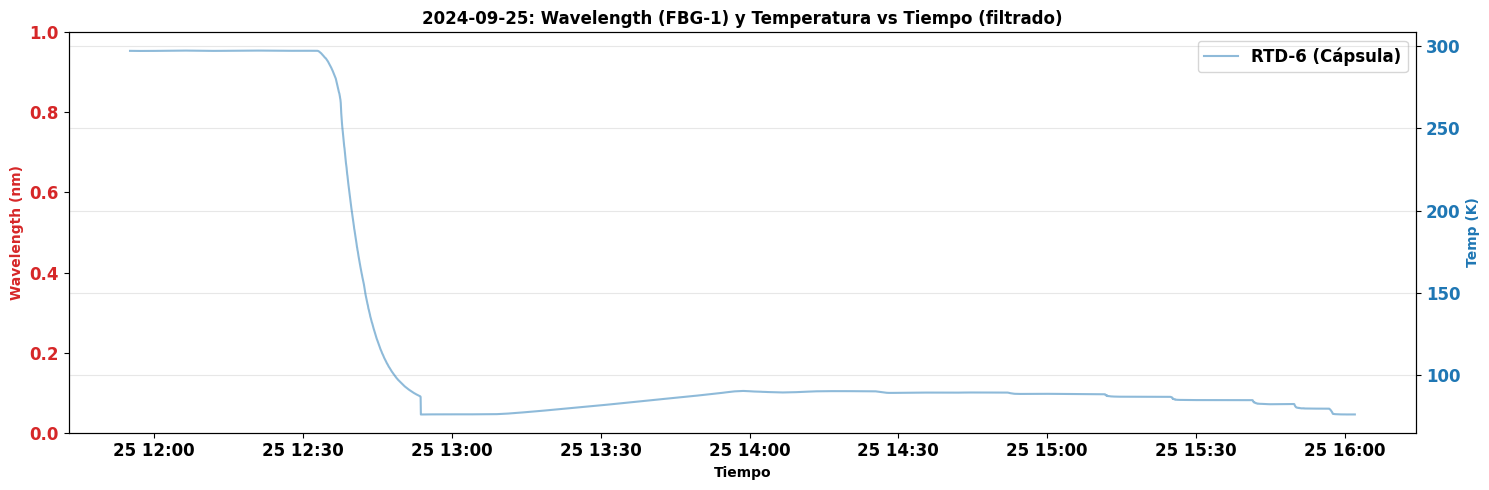

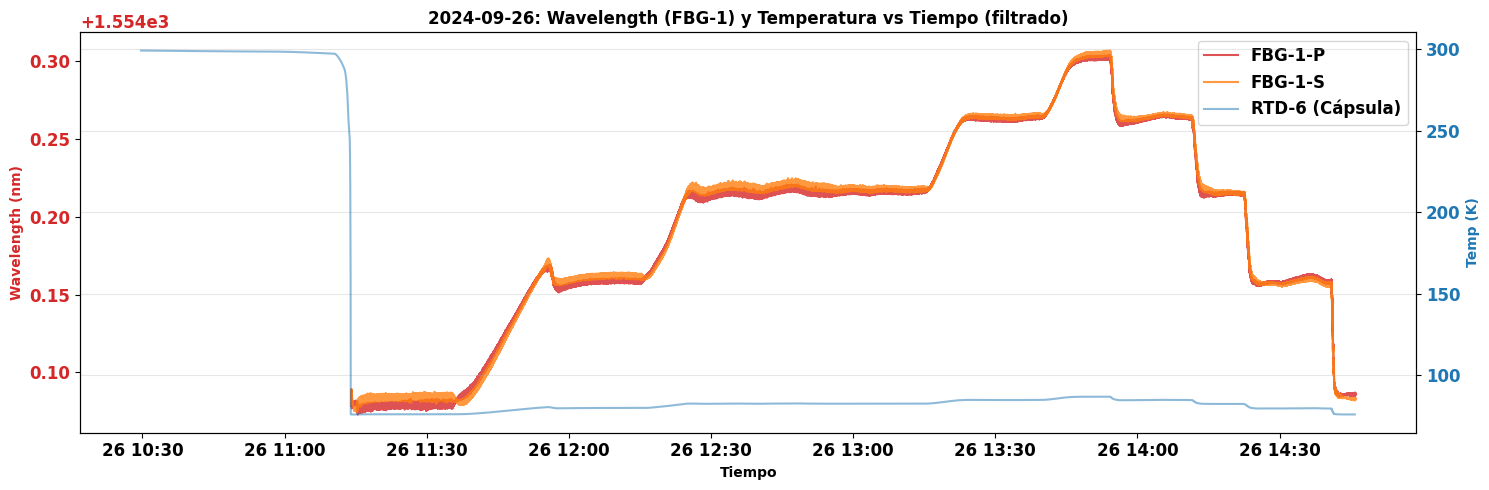

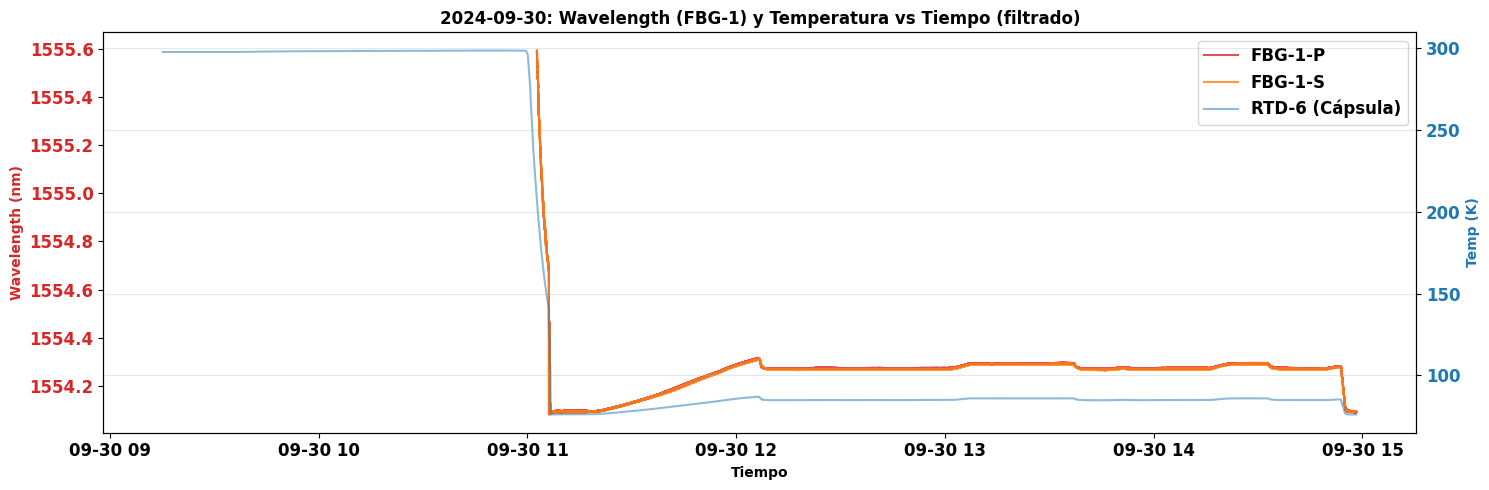

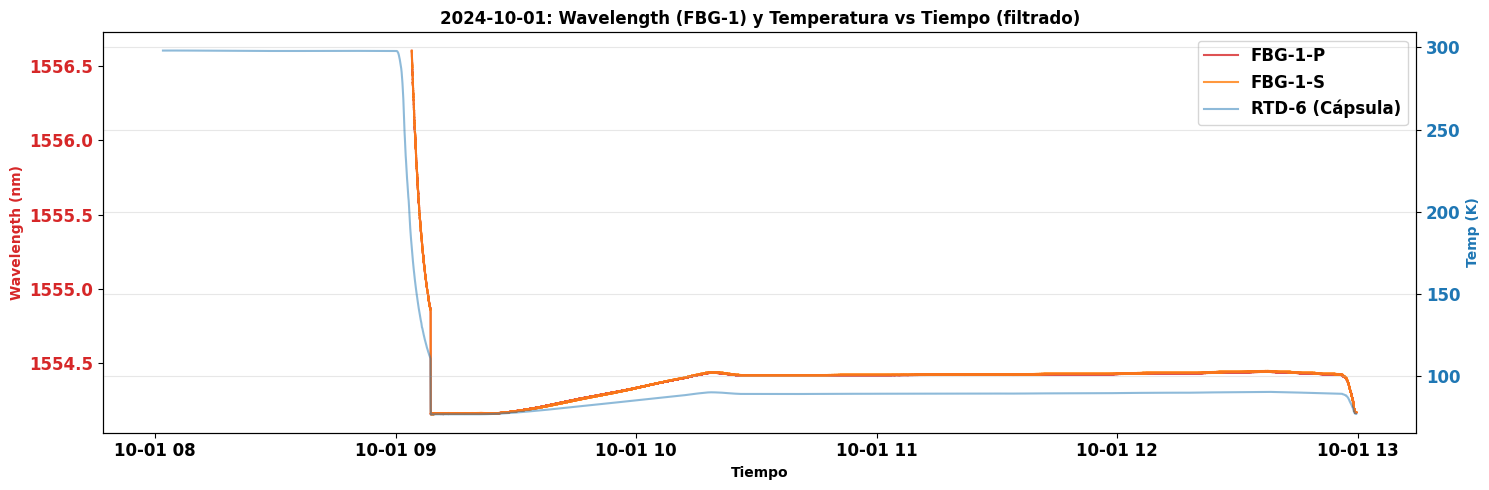

In [19]:
# Visualización para cada archivo: 'wav' (ambas polarizaciones) y 'temp' (RTD cápsula)
# Eje izquierdo: longitud de onda (nm), eje derecho: temperatura (K)
for fecha in datos:
    fig, ax1 = plt.subplots(figsize=(15,5))
    wav = datos[fecha]['wav']
    times = np.array(datos[fecha]['times_peak'])
    temp = datos[fecha]['temp_val']
    times_temp = datos[fecha]['times_temp']
    # --- CORRECCIÓN PARA 25-09-2024: asegurar alineación de longitud de onda y tiempo ---
    if fecha == '2024-09-25':
        # Si wav y times tienen diferente longitud, recortar ambos al mínimo común
        min_len = min(len(times), wav.shape[0])
        if len(times) != wav.shape[0]:
            print(f"Alineando longitud de onda y tiempos para {fecha}: cortando a {min_len} muestras")
        times = times[:min_len]
        wav = wav[:min_len]
    # Asegurarse de que wav es 2D y times es 1D
    if wav.ndim == 1:
        wav = wav[:, np.newaxis]
    elif wav.ndim > 2:
        wav = wav.reshape(wav.shape[0], -1)
    if times.ndim > 1:
        times = times.flatten()
    # Comprobar dimensiones
    shape = wav.shape
    if len(shape) == 2:
        n_samples, n_pols = shape
    elif len(shape) == 1:
        n_samples = shape[0]
        n_pols = 1
        wav = wav[:, np.newaxis]
    else:
        raise ValueError(f"Forma inesperada de wav: {shape}")
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    for idx_pol in range(n_pols):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav[:, idx_pol]
        mask_valid = ~np.isnan(wav_pol)
        # Solo graficar si hay datos válidos y dimensiones coinciden
        if np.sum(mask_valid) > 0 and len(times) == len(wav_pol):
            ax1.plot(times[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax1.set_xlabel('Tiempo')
    ax1.set_ylabel('Wavelength (nm)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    # Eje derecho para temperatura
    if temp.ndim == 2 and temp.shape[1] > 6:
        ax2 = ax1.twinx()
        ax2.plot(times_temp, temp[:,6], label='RTD-6 (Cápsula)', color='tab:blue', alpha=0.5)
        ax2.set_ylabel('Temp (K)', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    if temp.ndim == 2 and temp.shape[1] > 6:
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines += lines2
        labels += labels2
    ax1.legend(lines, labels, loc='best')
    plt.title(f"{fecha}: Wavelength (FBG-1) y Temperatura vs Tiempo (filtrado)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

wav_orig shape: (1567500, 2, 1)
times_temp shape: (6806,)
Pol P: 6806 valores > 0 de 6806
Pol S: 6806 valores > 0 de 6806


/tmp/vgarciap/ipykernel_541366/4209069616.py:21: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  times_plot_dt = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_plot])


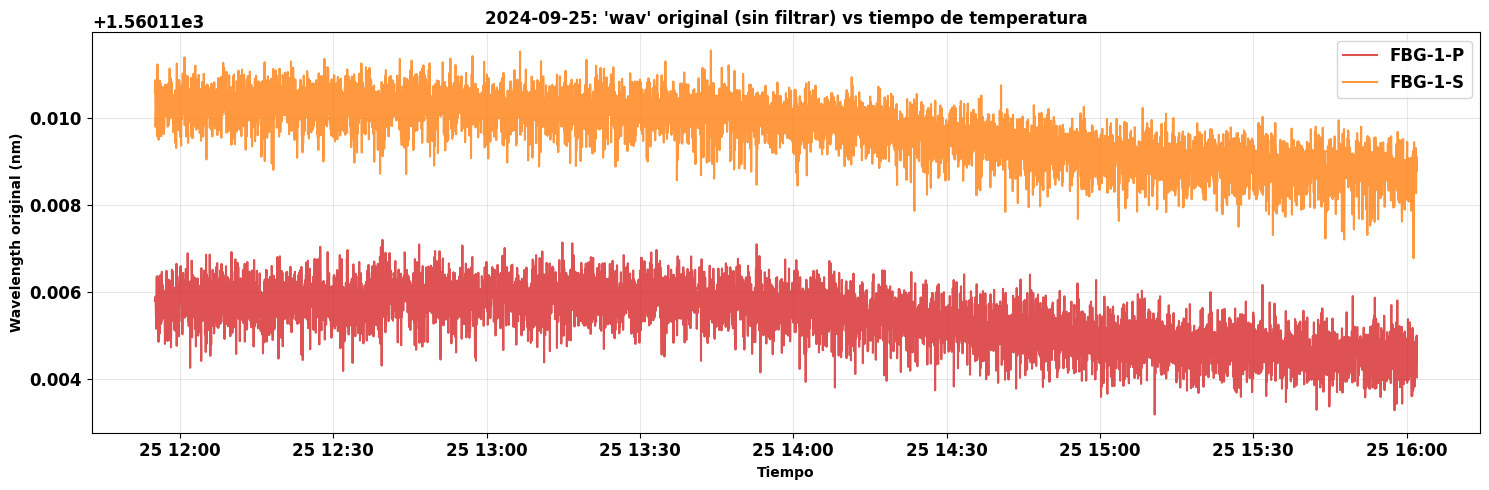

In [20]:
# Diagnóstico: graficar los primeros valores válidos originales de 'wav' frente a los tiempos de temperatura para el día 25-09-2024
fecha = '2024-09-25'
if fecha in datos:
    peak = datos[fecha]['peak']
    temp = datos[fecha]['temp']
    # Extraer los datos originales (sin filtrar ni escalar)
    wav_orig = peak['wav']
    times_temp = temp['t']
    print(f"wav_orig shape: {wav_orig.shape}")
    print(f"times_temp shape: {times_temp.shape}")
    # Si wav_orig es 3D, reducir a 2D (N,2)
    if wav_orig.ndim == 3 and wav_orig.shape[2] == 1:
        wav_orig = wav_orig[:,:,0]
    # Escalar a nm
    wav_orig_nm = wav_orig * 1e9
    # Alinear: usar solo los primeros N puntos donde N = min(len(times_temp), wav_orig.shape[0])
    min_len = min(len(times_temp), wav_orig_nm.shape[0])
    wav_plot = wav_orig_nm[:min_len]
    times_plot = times_temp[:min_len]
    # Convertir tiempos a datetime
    times_plot_dt = np.array([datetime.datetime.utcfromtimestamp(float(t)) for t in times_plot])
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    fig, ax = plt.subplots(figsize=(15,5))
    for idx_pol in range(wav_plot.shape[1]):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav_plot[:, idx_pol]
        mask_valid = wav_pol > 0
        print(f"Pol {pol}: {np.sum(mask_valid)} valores > 0 de {len(wav_pol)}")
        if np.sum(mask_valid) > 0:
            ax.plot(times_plot_dt[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax.set_xlabel('Tiempo')
    ax.set_ylabel('Wavelength original (nm)')
    ax.legend()
    plt.title(f"{fecha}: 'wav' original (sin filtrar) vs tiempo de temperatura")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"No hay datos para {fecha}")


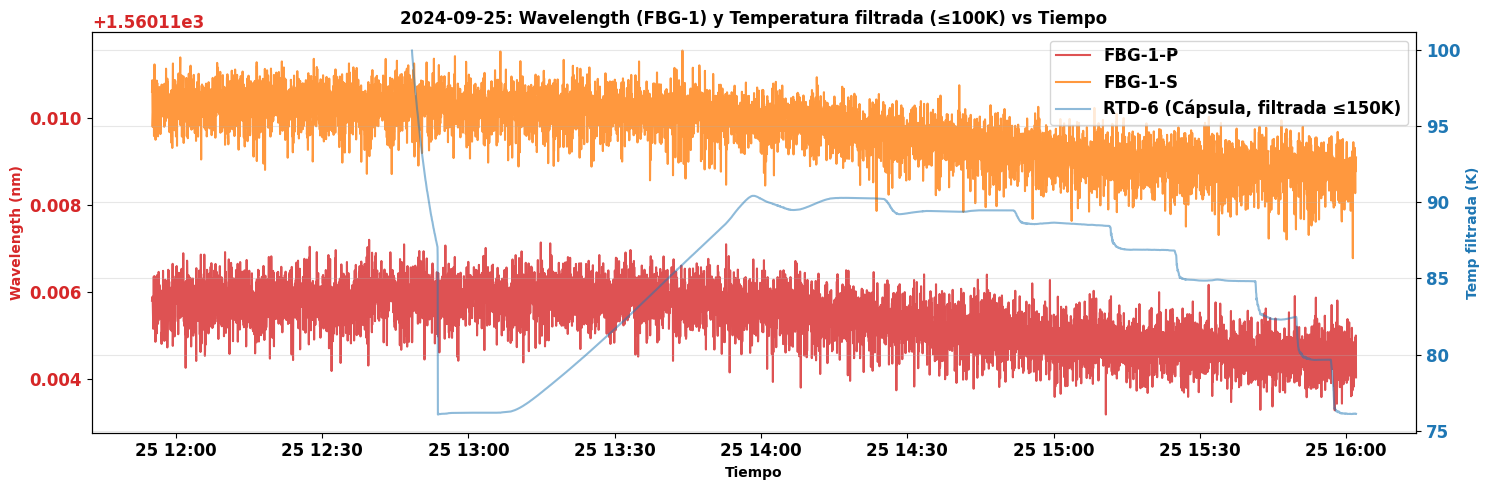

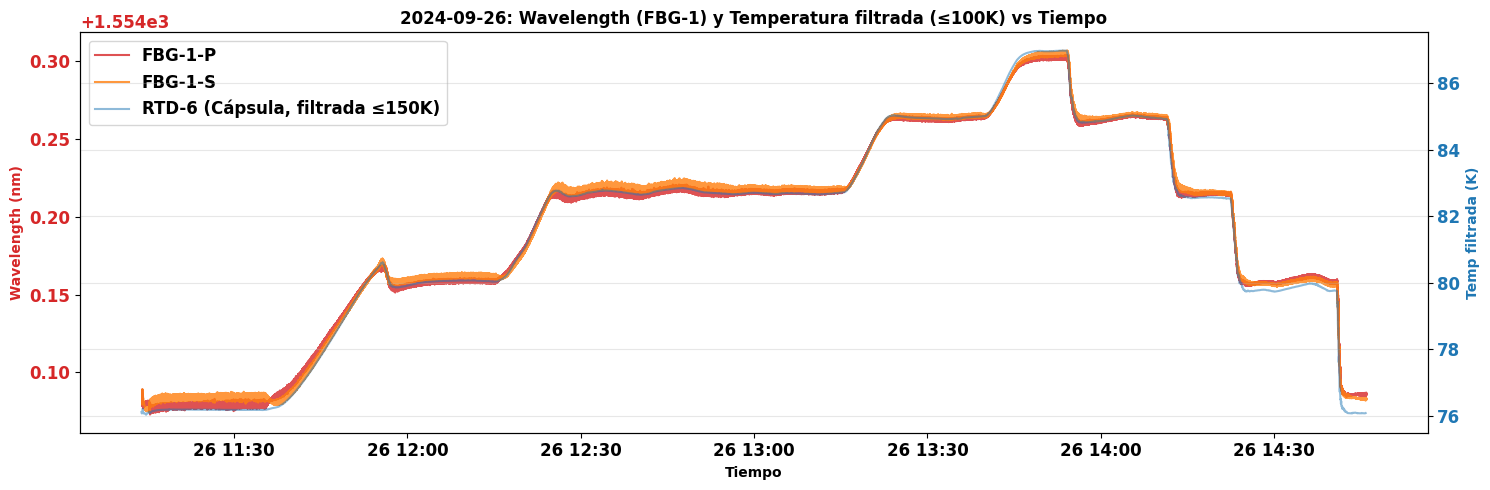

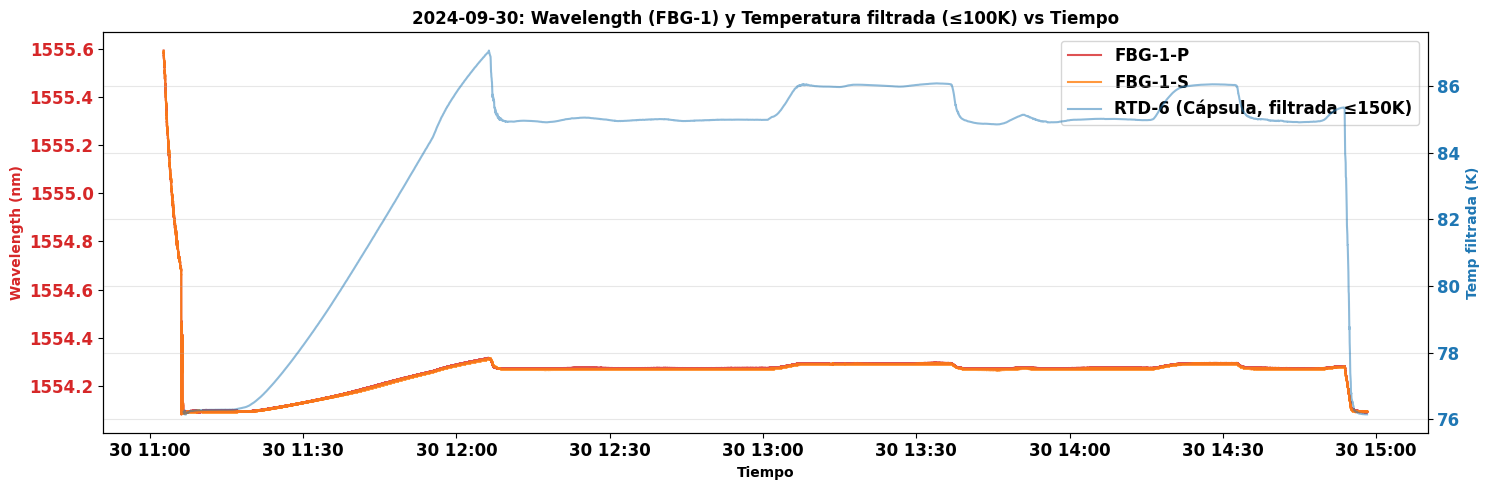

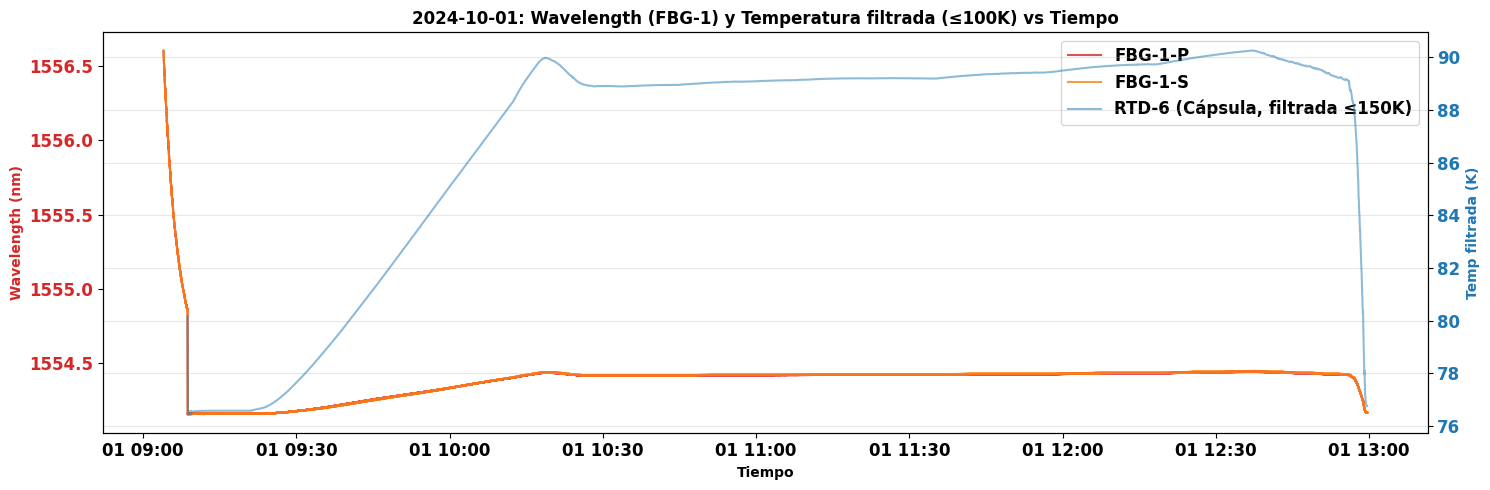

In [21]:
# Visualización para cada archivo: 'wav' (ambas polarizaciones) y 'temp' (RTD cápsula, filtrada a <=100K)
# Eje izquierdo: longitud de onda (nm), eje derecho: temperatura filtrada (K)
for fecha in datos:
    fig, ax1 = plt.subplots(figsize=(15,5))
    wav = datos[fecha]['wav']
    times = np.array(datos[fecha]['times_peak'])
    temp = datos[fecha]['temp_val']
    times_temp = datos[fecha]['times_temp']
    # --- CORRECCIÓN PARA 25-09-2024: usar los valores originales de wav si el filtrado deja todo NaN ---
    if fecha == '2024-09-25':
        peak = datos[fecha]['peak']
        wav_orig = peak['wav']
        if wav_orig.ndim == 3 and wav_orig.shape[2] == 1:
            wav_orig = wav_orig[:,:,0]
        wav_orig_nm = wav_orig * 1e9
        min_len = min(len(times), wav_orig_nm.shape[0])
        wav = wav_orig_nm[:min_len]
        times = times[:min_len]
        # Asegurarse de que wav es 2D
        if wav.ndim == 1:
            wav = wav[:, np.newaxis]
        elif wav.ndim > 2:
            wav = wav.reshape(wav.shape[0], -1)
        if times.ndim > 1:
            times = times.flatten()
    else:
        # Asegurarse de que wav es 2D y times es 1D
        if wav.ndim == 1:
            wav = wav[:, np.newaxis]
        elif wav.ndim > 2:
            wav = wav.reshape(wav.shape[0], -1)
        if times.ndim > 1:
            times = times.flatten()
    # Comprobar dimensiones
    shape = wav.shape
    if len(shape) == 2:
        n_samples, n_pols = shape
    elif len(shape) == 1:
        n_samples = shape[0]
        n_pols = 1
        wav = wav[:, np.newaxis]
    else:
        raise ValueError(f"Forma inesperada de wav: {shape}")
    pol_labels = ['P', 'S']
    colors = ['tab:red', 'tab:orange']
    for idx_pol in range(n_pols):
        pol = pol_labels[idx_pol] if idx_pol < len(pol_labels) else f'Pol{idx_pol}'
        wav_pol = wav[:, idx_pol]
        mask_valid = wav_pol > 0
        # Solo graficar si hay datos válidos y dimensiones coinciden
        if np.sum(mask_valid) > 0 and len(times) == len(wav_pol):
            ax1.plot(times[mask_valid], wav_pol[mask_valid], label=f'FBG-1-{pol}', color=colors[idx_pol%len(colors)], alpha=0.8)
    ax1.set_xlabel('Tiempo')
    ax1.set_ylabel('Wavelength (nm)', color='tab:red')
    ax1.tick_params(axis='y', labelcolor='tab:red')
    # Eje derecho para temperatura filtrada
    if temp.ndim == 2 and temp.shape[1] > 6:
        temp_filt = np.copy(temp[:,6])
        temp_filt[temp_filt > 100] = np.nan
        ax2 = ax1.twinx()
        ax2.plot(times_temp, temp_filt, label='RTD-6 (Cápsula, filtrada ≤150K)', color='tab:blue', alpha=0.5)
        ax2.set_ylabel('Temp filtrada (K)', color='tab:blue')
        ax2.tick_params(axis='y', labelcolor='tab:blue')
    # Leyenda combinada
    lines, labels = ax1.get_legend_handles_labels()
    if temp.ndim == 2 and temp.shape[1] > 6:
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines += lines2
        labels += labels2
    ax1.legend(lines, labels, loc='best')
    plt.title(f"{fecha}: Wavelength (FBG-1) y Temperatura filtrada (≤100K) vs Tiempo")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## 5️⃣ Selección provisional de plateaus (editable)
Definimos intervalos provisionales de plateaus para cada archivo y polarización. Estos valores deben editarse manualmente tras inspección visual.

In [22]:
# Intervalos de plateaus definidos manualmente tras inspección
# Formato: {fecha: {polarizacion: [(t_ini, t_fin), ...]}}
plateaus = {
    # '2024-09-25': {  # No se definen plateaus para este día por falta de datos válidos
    #     'P': [],
    #     'S': [],
    # },
    '2024-09-26': {
        'P': [
            (datetime.datetime(2024,9,26,11,19), datetime.datetime(2024,9,26,11,32)),
            (datetime.datetime(2024,9,26,12,0), datetime.datetime(2024,9,26,12,11)),
            (datetime.datetime(2024,9,26,13,0), datetime.datetime(2024,9,26,13,10)),
            (datetime.datetime(2024,9,26,13,28), datetime.datetime(2024,9,26,13,34)),
            (datetime.datetime(2024,9,26,13,49), datetime.datetime(2024,9,26,13,53)),
            (datetime.datetime(2024,9,26,14,0), datetime.datetime(2024,9,26,14,7)),
            (datetime.datetime(2024,9,26,14,14), datetime.datetime(2024,9,26,14,20)),
            (datetime.datetime(2024,9,26,14,30), datetime.datetime(2024,9,26,14,39)),
        ],
        'S': [
            (datetime.datetime(2024,9,26,11,19), datetime.datetime(2024,9,26,11,32)),
            (datetime.datetime(2024,9,26,12,0), datetime.datetime(2024,9,26,12,11)),
            (datetime.datetime(2024,9,26,13,0), datetime.datetime(2024,9,26,13,10)),
            (datetime.datetime(2024,9,26,13,28), datetime.datetime(2024,9,26,13,34)),
            (datetime.datetime(2024,9,26,13,49), datetime.datetime(2024,9,26,13,53)),
            (datetime.datetime(2024,9,26,14,0), datetime.datetime(2024,9,26,14,7)),
            (datetime.datetime(2024,9,26,14,14), datetime.datetime(2024,9,26,14,20)),
            (datetime.datetime(2024,9,26,14,30), datetime.datetime(2024,9,26,14,39)),
        ],
    },
    '2024-09-30': {
        'P': [
            (datetime.datetime(2024,9,30,11,9), datetime.datetime(2024,9,30,11,12)),
            (datetime.datetime(2024,9,30,12,30), datetime.datetime(2024,9,30,13,0)),
            (datetime.datetime(2024,9,30,13,16), datetime.datetime(2024,9,30,13,32)),
            (datetime.datetime(2024,9,30,13,50), datetime.datetime(2024,9,30,14,8)),
            (datetime.datetime(2024,9,30,14,25), datetime.datetime(2024,9,30,14,31)),
            (datetime.datetime(2024,9,30,14,40), datetime.datetime(2024,9,30,14,50)),
        ],
        'S': [
            (datetime.datetime(2024,9,30,11,9), datetime.datetime(2024,9,30,11,12)),
            (datetime.datetime(2024,9,30,12,30), datetime.datetime(2024,9,30,13,0)),
            (datetime.datetime(2024,9,30,13,16), datetime.datetime(2024,9,30,13,32)),
            (datetime.datetime(2024,9,30,13,50), datetime.datetime(2024,9,30,14,8)),
            (datetime.datetime(2024,9,30,14,25), datetime.datetime(2024,9,30,14,31)),
            (datetime.datetime(2024,9,30,14,40), datetime.datetime(2024,9,30,14,50)),
        ],
    },
    '2024-10-01': {
        'P': [
            (datetime.datetime(2024,10,1,9,11), datetime.datetime(2024,10,1,9,17)),
            (datetime.datetime(2024,10,1,10,51), datetime.datetime(2024,10,1,11,00)),
            (datetime.datetime(2024,10,1,11,3), datetime.datetime(2024,10,1,12,0)),
        ],
        'S': [
            (datetime.datetime(2024,10,1,9,11), datetime.datetime(2024,10,1,9,17)),
            (datetime.datetime(2024,10,1,10,51), datetime.datetime(2024,10,1,11,00)),
            (datetime.datetime(2024,10,1,11,3), datetime.datetime(2024,10,1,12,0)),
        ],
    },
}
print("Plateaus definidos manualmente según inspección visual. El 25-09-2024 se omite por falta de datos de 'wav' válidos.")

Plateaus definidos manualmente según inspección visual. El 25-09-2024 se omite por falta de datos de 'wav' válidos.


## 6️⃣ Detección y ajuste (fit) de plateaus para cada archivo
Detectamos los plateaus en los intervalos definidos y ajustamos (fit) los datos de cada plateau para extraer parámetros relevantes.

In [23]:
# Ajuste lineal de cada plateau para cada archivo y polarización (robusto a desajustes de longitud)
resultados_plateaus = {}
for fecha in datos:
    if fecha not in plateaus:
        print(f"⚠️ No hay plateaus definidos para {fecha}, se omite este run.")
        continue
    resultados_plateaus[fecha] = {}
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Interpolar wav a los tiempos de temperatura
        times_peak = np.array(datos[fecha]['times_peak'])
        if times_peak.ndim == 2:
            times_peak_1d = times_peak[:,0]
        else:
            times_peak_1d = times_peak
        wav = datos[fecha]['wav'][:,idx_pol]
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        mask_valid_wav = ~np.isnan(wav)
        # Robustez: comprobar longitudes antes de indexar
        if len(mask_valid_wav) != len(times_peak_1d):
            print(f"[AVISO] Desajuste de longitudes en {fecha} pol {pol}: len(mask_valid_wav)={len(mask_valid_wav)}, len(times_peak_1d)={len(times_peak_1d)}. No se interpola.")
            wav_interp = np.full_like(times_temp, np.nan)
        elif np.sum(mask_valid_wav) < 2:
            print(f"[AVISO] No hay suficientes datos válidos de wav para interpolar en {fecha} pol {pol}")
            wav_interp = np.full_like(times_temp, np.nan)
        else:
            try:
                wav_interp = np.interp(
                    [t.timestamp() for t in times_temp],
                    [t.timestamp() for t in times_peak_1d[mask_valid_wav]],
                    wav[mask_valid_wav],
                    left=np.nan, right=np.nan
                )
            except Exception as e:
                print(f"[ERROR] Interpolando wav en {fecha} pol {pol}: {e}")
                wav_interp = np.full_like(times_temp, np.nan)
        resultados_plateaus[fecha][pol] = []
        # Usar los plateaus definidos sobre los tiempos de temperatura
        masks = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        for i_mask, mask in enumerate(masks):
            # Diagnóstico de longitudes
            if len(mask) != len(temp) or len(mask) != len(wav_interp):
                print(f"[DIAGNÓSTICO] Desajuste de longitudes en {fecha} pol {pol} plateau {i_mask+1}:")
                print(f"  len(mask): {len(mask)}  len(temp): {len(temp)}  len(wav_interp): {len(wav_interp)}")
                min_len = min(len(mask), len(temp), len(wav_interp))
                mask = mask[:min_len]
                temp_c = temp[:min_len]
                wav_c = wav_interp[:min_len]
            else:
                temp_c = temp
                wav_c = wav_interp
            try:
                slope, std_err = fit_plateau(temp_c[mask], wav_c[mask])
                resultados_plateaus[fecha][pol].append({'slope': slope, 'std_err': std_err})
            except Exception as e:
                print(f"[ERROR] Fallo en fit_plateau para {fecha} pol {pol} plateau {i_mask+1}: {e}")
                print(f"  mask sum: {np.sum(mask)}  temp_c shape: {temp_c.shape}  wav_c shape: {wav_c.shape}")
                resultados_plateaus[fecha][pol].append({'slope': np.nan, 'std_err': np.nan})
print("Ajuste lineal realizado para cada plateau y polarización (robusto a desajustes de longitud).");


⚠️ No hay plateaus definidos para 2024-09-25, se omite este run.
Ajuste lineal realizado para cada plateau y polarización (robusto a desajustes de longitud).


In [24]:
# For each plateau, print mean temperature and wavelength, but do NOT plot to avoid notebook overload
def media_y_error(x):
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return np.mean(x), np.std(x)/np.sqrt(len(x)) if len(x) > 1 else (np.mean(x), np.nan)

for fecha in datos:
    if fecha not in plateaus:
        continue
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Plateaus over temperature times
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        masks_temp = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        # Plateaus over peak times
        times_peak = np.array(datos[fecha]['times_peak'])
        wav = datos[fecha]['wav'][:,idx_pol]
        masks_wav = seleccionar_plateaus(times_peak, plateaus[fecha][pol])
        for i_mask, (mask_t, mask_w) in enumerate(zip(masks_temp, masks_wav)):
            t_mean, t_err = media_y_error(temp[mask_t])
            w_mean, w_err = media_y_error(wav[mask_w])
            print(f"--- {fecha} pol {pol} plateau {i_mask+1} ---")
            print(f"  temp: {t_mean:.3f} ± {t_err:.3g}  wav: {w_mean:.3f} ± {w_err:.3g}")
            # The following plot is commented to avoid notebook overload
            # import matplotlib.pyplot as plt
            # fig, ax1 = plt.subplots(figsize=(7,4))
            # ax1.plot(temp[mask_t], np.full(np.sum(mask_t), w_mean), 'o', label='Temp plateau', color='tab:blue', alpha=0.5)
            # ax1.plot(np.full(np.sum(mask_w), t_mean), wav[mask_w], 'o', label='Wav plateau', color='tab:red', alpha=0.5)
            # ax1.errorbar(t_mean, w_mean, xerr=t_err, yerr=w_err, fmt='s', color='k', label='Mean ± error')
            # ax1.set_xlabel('Temp (K)')
            # ax1.set_ylabel('Wavelength (nm)')
            # ax1.set_title(f'{fecha} {pol} plateau {i_mask+1} (independent means)')
            # ax1.legend()
            # plt.tight_layout()
            # plt.show()


--- 2024-09-26 pol P plateau 1 ---
  temp: 76.190 ± 0.000192  wav: 1554.079 ± 2.47e-06
--- 2024-09-26 pol P plateau 2 ---
  temp: 80.032 ± 0.0024  wav: 1554.158 ± 3.49e-06
--- 2024-09-26 pol P plateau 3 ---
  temp: 82.681 ± 0.000624  wav: 1554.216 ± 1.94e-06
--- 2024-09-26 pol P plateau 4 ---
  temp: 84.933 ± 0.000956  wav: 1554.263 ± 1.95e-06
--- 2024-09-26 pol P plateau 5 ---
  temp: 86.955 ± 0.000494  wav: 1554.302 ± 2.22e-06
--- 2024-09-26 pol P plateau 6 ---
  temp: 84.955 ± 0.00381  wav: 1554.264 ± 4.86e-06
--- 2024-09-26 pol P plateau 7 ---
  temp: 82.562 ± 0.00111  wav: 1554.215 ± 2.2e-06
--- 2024-09-26 pol P plateau 8 ---
  temp: 79.870 ± 0.00476  wav: 1554.160 ± 5.67e-06
--- 2024-09-26 pol S plateau 1 ---
  temp: 76.190 ± 0.000192  wav: 1554.084 ± 2.25e-06
--- 2024-09-26 pol S plateau 2 ---
  temp: 80.032 ± 0.0024  wav: 1554.161 ± 3.49e-06
--- 2024-09-26 pol S plateau 3 ---
  temp: 82.681 ± 0.000624  wav: 1554.218 ± 2.03e-06
--- 2024-09-26 pol S plateau 4 ---
  temp: 84.933 ±

## 7️⃣ Cálculo de sensibilidad para cada medida y polarización
Calculamos la sensibilidad para cada archivo y cada polarización a partir de los fits realizados en los plateaus.

[2024-09-26 P plateau 1] temp: 76.190±0.000192, wav: 1554.079±2.47e-06
[2024-09-26 P plateau 2] temp: 80.032±0.0024, wav: 1554.158±3.49e-06
[2024-09-26 P plateau 3] temp: 82.681±0.000624, wav: 1554.216±1.94e-06
[2024-09-26 P plateau 4] temp: 84.933±0.000956, wav: 1554.263±1.95e-06
[2024-09-26 P plateau 5] temp: 86.955±0.000494, wav: 1554.302±2.22e-06
[2024-09-26 P plateau 6] temp: 84.955±0.00381, wav: 1554.264±4.86e-06
[2024-09-26 P plateau 7] temp: 82.562±0.00111, wav: 1554.215±2.2e-06
[2024-09-26 P plateau 8] temp: 79.870±0.00476, wav: 1554.160±5.67e-06


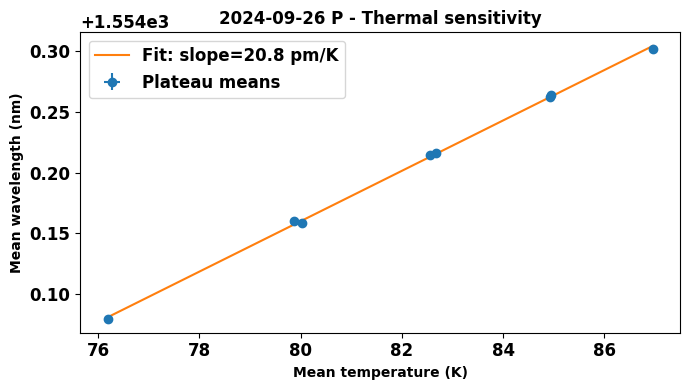

[2024-09-26 S plateau 1] temp: 76.190±0.000192, wav: 1554.084±2.25e-06
[2024-09-26 S plateau 2] temp: 80.032±0.0024, wav: 1554.161±3.49e-06
[2024-09-26 S plateau 3] temp: 82.681±0.000624, wav: 1554.218±2.03e-06
[2024-09-26 S plateau 4] temp: 84.933±0.000956, wav: 1554.264±2.17e-06
[2024-09-26 S plateau 5] temp: 86.955±0.000494, wav: 1554.304±2.81e-06
[2024-09-26 S plateau 6] temp: 84.955±0.00381, wav: 1554.265±4.37e-06
[2024-09-26 S plateau 7] temp: 82.562±0.00111, wav: 1554.216±4.11e-06
[2024-09-26 S plateau 8] temp: 79.870±0.00476, wav: 1554.159±5.07e-06


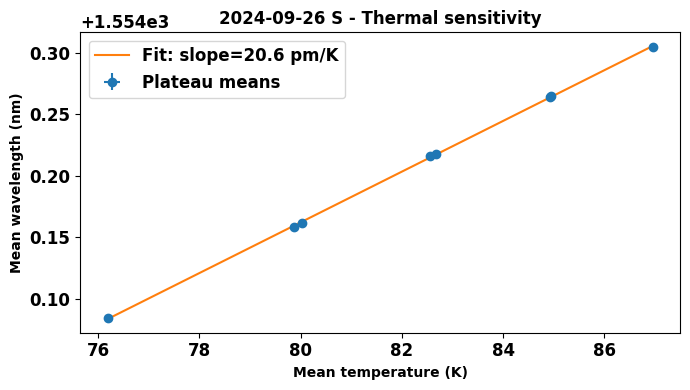

[2024-09-30 P plateau 1] temp: 76.276±0.000543, wav: 1554.095±1.39e-05
[2024-09-30 P plateau 2] temp: 84.977±0.000563, wav: 1554.274±1.2e-06
[2024-09-30 P plateau 3] temp: 86.016±0.000971, wav: 1554.294±1.7e-06
[2024-09-30 P plateau 4] temp: 84.992±0.00251, wav: 1554.274±2.99e-06
[2024-09-30 P plateau 5] temp: 86.043±0.000456, wav: 1554.295±2.16e-06
[2024-09-30 P plateau 6] temp: 84.934±0.00114, wav: 1554.273±1.78e-06


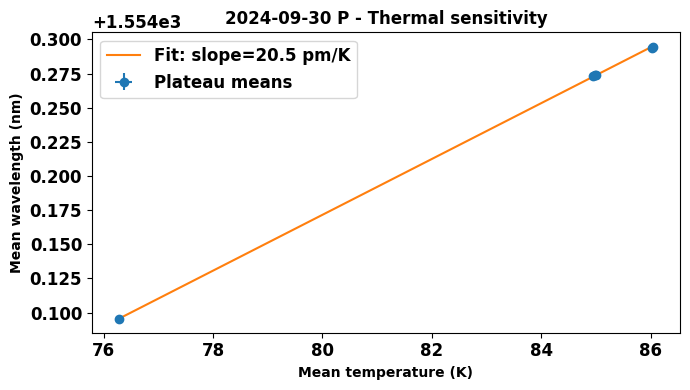

[2024-09-30 S plateau 1] temp: 76.276±0.000543, wav: 1554.093±1.2e-05
[2024-09-30 S plateau 2] temp: 84.977±0.000563, wav: 1554.269±1.14e-06
[2024-09-30 S plateau 3] temp: 86.016±0.000971, wav: 1554.291±1.7e-06
[2024-09-30 S plateau 4] temp: 84.992±0.00251, wav: 1554.270±3.03e-06
[2024-09-30 S plateau 5] temp: 86.043±0.000456, wav: 1554.292±2.07e-06
[2024-09-30 S plateau 6] temp: 84.934±0.00114, wav: 1554.270±1.72e-06


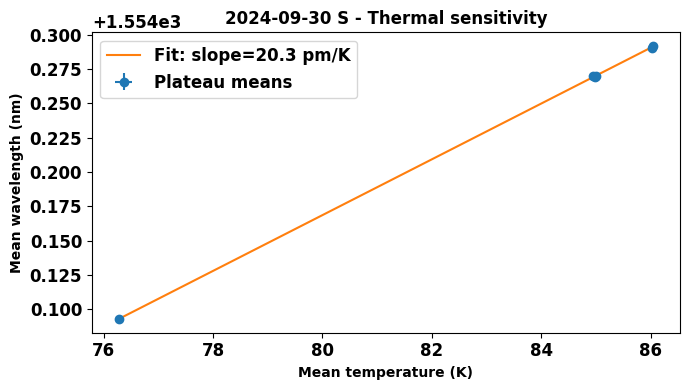

[2024-10-01 P plateau 1] temp: 76.580±0.000287, wav: 1554.160±4.84e-06
[2024-10-01 P plateau 2] temp: 89.063±0.000917, wav: 1554.418±1.68e-06
[2024-10-01 P plateau 3] temp: 89.255±0.00257, wav: 1554.422±3.17e-06


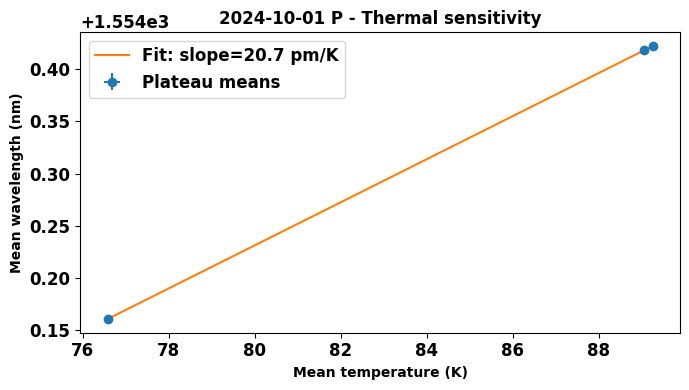

[2024-10-01 S plateau 1] temp: 76.580±0.000287, wav: 1554.161±4.09e-06
[2024-10-01 S plateau 2] temp: 89.063±0.000917, wav: 1554.421±1.67e-06
[2024-10-01 S plateau 3] temp: 89.255±0.00257, wav: 1554.426±3.37e-06


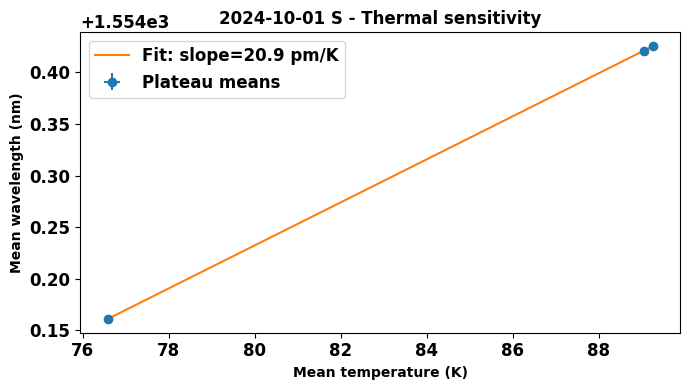

,fecha,polarizacion,slope,std_err
0,2024-09-26,P,0.020784,0.000226
1,2024-09-26,S,0.020622,0.000108
2,2024-09-30,P,0.020451,0.000083
3,2024-09-30,S,0.020339,0.000089
4,2024-10-01,P,0.020664,0.000009
5,2024-10-01,S,0.020856,0.000035


In [25]:
# Global sensitivity: linear fit of means of each plateau (wav_mean vs temp_mean) using independent means per channel, in pm/K
from scipy.stats import linregress

def media_y_error(x):
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    return np.mean(x), np.std(x)/np.sqrt(len(x)) if len(x) > 1 else (np.mean(x), np.nan)

sensibilidad_global = []
for fecha in datos:
    if fecha not in plateaus:
        continue
    for pol, idx_pol in zip(['P','S'], [0,1]):
        # Plateaus over temperature times
        times_temp = np.array(datos[fecha]['times_temp'])
        temp = datos[fecha]['temp_val'][:,6] if datos[fecha]['temp_val'].shape[1]>6 else np.full_like(times_temp, np.nan)
        masks_temp = seleccionar_plateaus(times_temp, plateaus[fecha][pol])
        # Plateaus over peak times
        times_peak = np.array(datos[fecha]['times_peak'])
        wav = datos[fecha]['wav'][:,idx_pol]
        masks_wav = seleccionar_plateaus(times_peak, plateaus[fecha][pol])
        temp_medias, temp_errs, wav_medias, wav_errs = [], [], [], []
        for i_mask, (mask_t, mask_w) in enumerate(zip(masks_temp, masks_wav)):
            t_mean, t_err = media_y_error(temp[mask_t])
            w_mean, w_err = media_y_error(wav[mask_w])
            temp_medias.append(t_mean)
            temp_errs.append(t_err)
            wav_medias.append(w_mean)
            wav_errs.append(w_err)
            print(f"[{fecha} {pol} plateau {i_mask+1}] temp: {t_mean:.3f}±{t_err:.3g}, wav: {w_mean:.3f}±{w_err:.3g}")
        temp_medias = np.array(temp_medias)
        wav_medias = np.array(wav_medias)
        temp_errs = np.array(temp_errs)
        wav_errs = np.array(wav_errs)
        mask_valid = ~np.isnan(temp_medias) & ~np.isnan(wav_medias)
        if np.sum(mask_valid) > 1:
            slope, intercept, r, p, std_err = linregress(temp_medias[mask_valid], wav_medias[mask_valid])
            sensibilidad_global.append({'fecha': fecha, 'polarizacion': pol, 'slope': slope, 'std_err': std_err})
            # Plot with error bars, in pm/K
            plt.figure(figsize=(7,4))
            plt.errorbar(temp_medias, wav_medias, xerr=temp_errs, yerr=wav_errs, fmt='o', label='Plateau means')
            xfit = np.linspace(np.nanmin(temp_medias[mask_valid]), np.nanmax(temp_medias[mask_valid]), 50)
            yfit = slope*xfit + intercept
            plt.plot(xfit, yfit, '-', label=f'Fit: slope={slope*1000:.1f} pm/K')
            plt.xlabel('Mean temperature (K)')
            plt.ylabel('Mean wavelength (nm)')
            plt.title(f'{fecha} {pol} - Thermal sensitivity')
            plt.legend()
            plt.tight_layout()
            plt.show()
        else:
            print(f'[WARNING] Not enough valid plateaus for fit in {fecha} {pol}')
# Show summary table of global sensitivities
import pandas as pd
df_sens_global = pd.DataFrame(sensibilidad_global)
display(df_sens_global)


# 8️⃣ Plot de repetibilidad de sensibilidades
Graficamos las sensibilidades obtenidas para las cuatro medidas y ambas polarizaciones, mostrando la repetibilidad.

## 9️⃣ Tabla resumen de sensibilidades por archivo y polarización
Tabla resumen con las sensibilidades obtenidas para cada archivo y polarización, lista para exportar o analizar.

In [26]:
# Mostrar tabla resumen de sensibilidades globales (no por plateau)
print("Tabla resumen de sensibilidades globales (nm/K):")
display(df_sens_global)
# Para exportar: df_sens_global.to_csv('sensibilidades_globales_peek1_450um_4dias.csv', index=False)

Tabla resumen de sensibilidades globales (nm/K):


,fecha,polarizacion,slope,std_err
0,2024-09-26,P,0.020784,0.000226
1,2024-09-26,S,0.020622,0.000108
2,2024-09-30,P,0.020451,0.000083
3,2024-09-30,S,0.020339,0.000089
4,2024-10-01,P,0.020664,0.000009
5,2024-10-01,S,0.020856,0.000035


## 🔟 Plot típico: P y S vs Temperatura con Plateaus Sombreados (FBG-1)

Celda adaptada al caso de **un único sensor (FBG-1)** y múltiples fechas.  
Muestra temperatura (RTD-6) + polarizaciones P/S en eje secundario, con bandas sombreadas de plateau.

/tmp/vgarciap/ipykernel_541366/2309980892.py:101: RuntimeWarning: Mean of empty slice
  wav_mean = np.nanmean(stacked, axis=0)


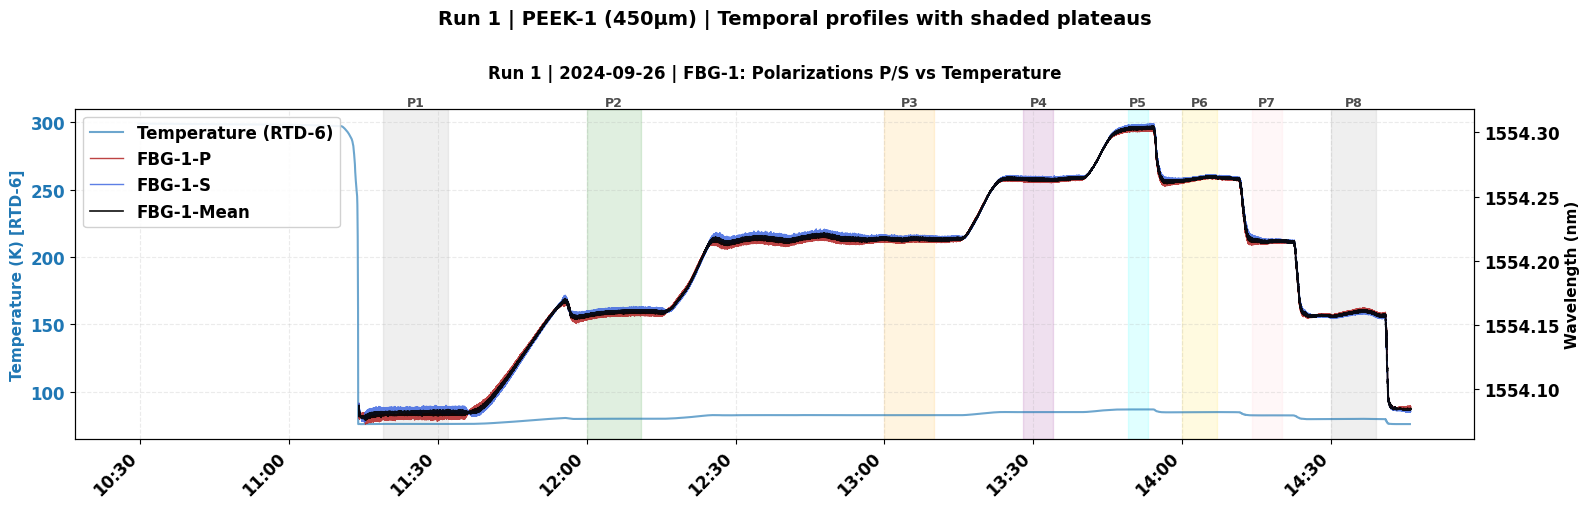

✅ Shaded-plateau plot generated for 2024-09-26 (n_sensors=1, run=1).


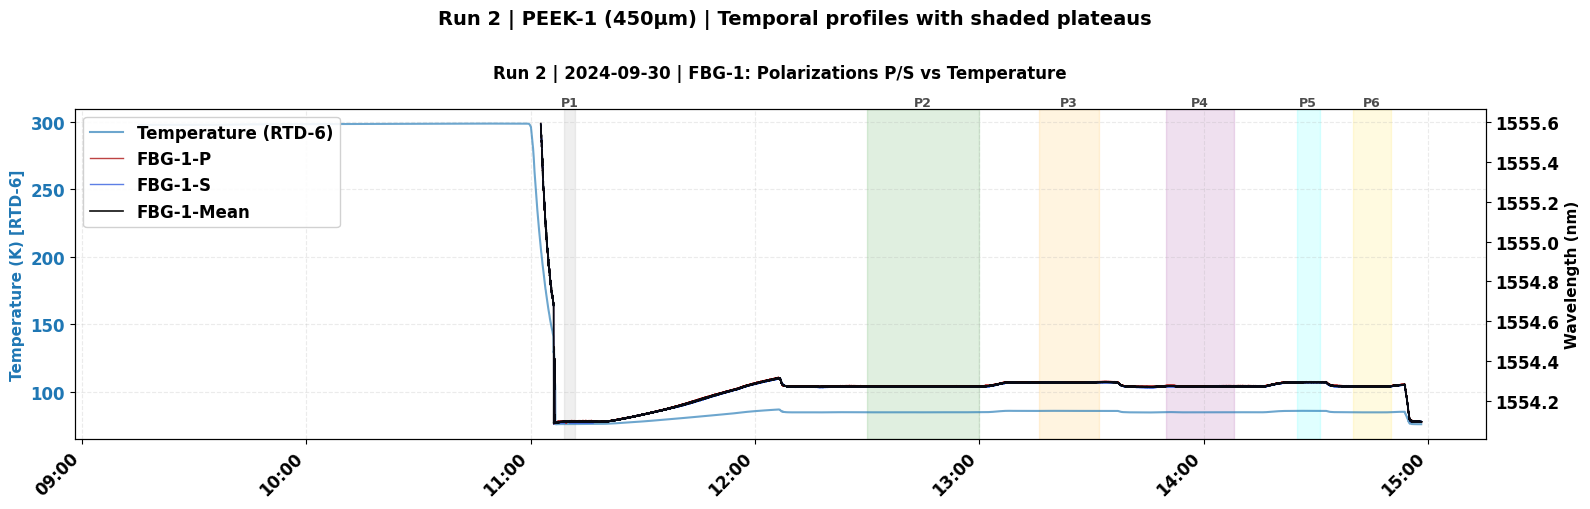

✅ Shaded-plateau plot generated for 2024-09-30 (n_sensors=1, run=2).


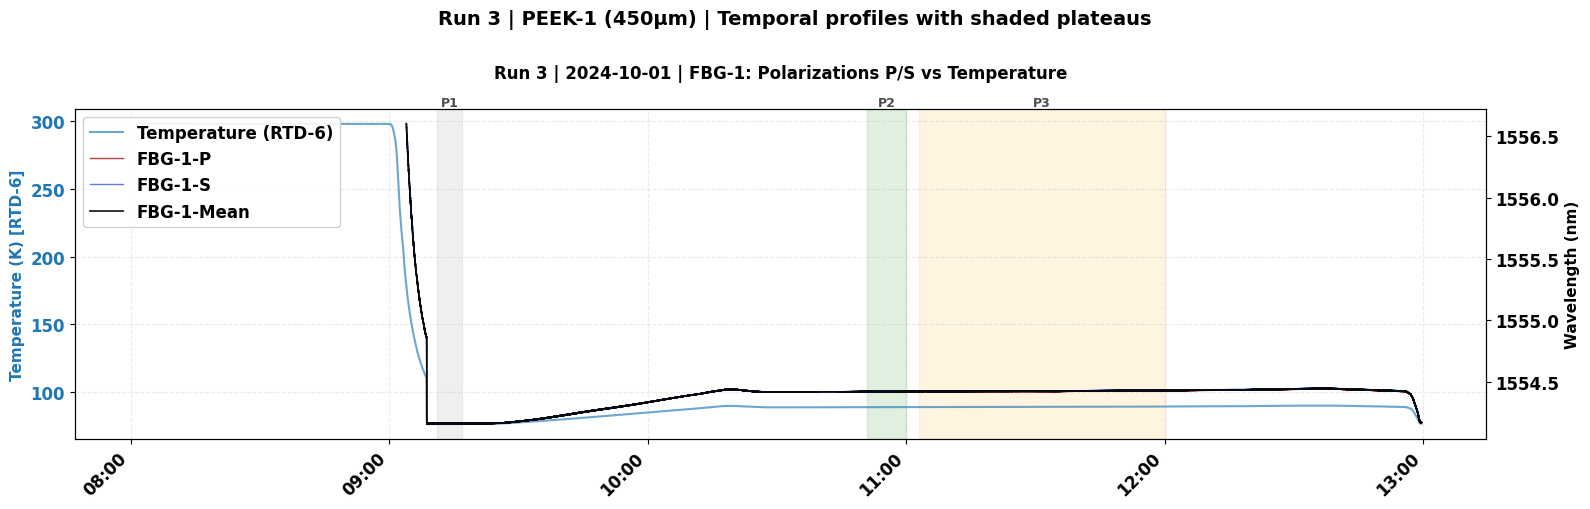

✅ Shaded-plateau plot generated for 2024-10-01 (n_sensors=1, run=3).


In [27]:
# ============================================================================
# PLOT: FBGs (P & S) vs Temperature with Shaded Plateaus
# Iterate by date and detected sensor (supports 1 or more sensors)
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

color_temp = 'tab:blue'
color_pol_p = 'firebrick'
color_pol_s = 'royalblue'
plateau_colors = ['gray', 'green', 'orange', 'purple', 'cyan', 'gold', 'pink']

fechas_plot = [f for f in sorted(datos.keys()) if f in plateaus]
if len(fechas_plot) == 0:
    print("⚠️ No dates with plateaus defined.")
else:
    for run_idx, fecha in enumerate(fechas_plot, start=1):
        wav_all = np.array(datos[fecha]['wav'])
        times_peak = np.array(datos[fecha]['times_peak'])
        times_temp = np.array(datos[fecha]['times_temp'])
        temp_raw = np.array(datos[fecha]['temp_val'])
        temp_ref = temp_raw[:, 6] if (temp_raw.ndim == 2 and temp_raw.shape[1] > 6) else np.full(len(times_temp), np.nan)

        # Detect number of sensors and polarizations
        if wav_all.ndim == 3:
            if wav_all.shape[1] in (1,2):
                n_pols = wav_all.shape[1]
                n_sensors = wav_all.shape[2]
            elif wav_all.shape[2] in (1,2):
                n_pols = wav_all.shape[2]
                n_sensors = wav_all.shape[1]
            else:
                n_pols = wav_all.shape[1]
                n_sensors = wav_all.shape[2]
        elif wav_all.ndim == 2:
            n_pols = wav_all.shape[1]
            n_sensors = 1
        else:
            n_pols = 1
            n_sensors = 1

        # Prepare figure with one row per sensor
        fig, axes = plt.subplots(n_sensors, 1, figsize=(16, 5 * n_sensors), sharex=True)
        fig.subplots_adjust(hspace=0.35)
        if n_sensors == 1:
            axes = [axes]

        for sensor_idx in range(n_sensors):
            ax1 = axes[sensor_idx]

            # Prepare wav by polarization for this sensor
            if wav_all.ndim == 2 and n_sensors == 1:
                wav_p = wav_all[:, 0] if wav_all.shape[1] > 0 else np.full(len(times_peak), np.nan)
                wav_s = wav_all[:, 1] if wav_all.shape[1] > 1 else np.full(len(times_peak), np.nan)
            elif wav_all.ndim == 3:
                # assume (N, pols, sensors)
                try:
                    wav_p = wav_all[:, 0, sensor_idx]
                    wav_s = wav_all[:, 1, sensor_idx]
                except Exception:
                    # fallback: (N, sensors, pols)
                    wav_p = wav_all[:, sensor_idx, 0]
                    wav_s = wav_all[:, sensor_idx, 1] if wav_all.shape[2] > 1 else np.full(len(times_peak), np.nan)
            else:
                wav_p = np.full(len(times_peak), np.nan)
                wav_s = np.full(len(times_peak), np.nan)

            mask_p = ~np.isnan(wav_p) & (wav_p > 0)
            mask_s = ~np.isnan(wav_s) & (wav_s > 0)
            mask_temp = ~np.isnan(temp_ref) & (temp_ref > 0)

            # Left axis: temperature
            ax1.set_ylabel(f'Temperature (K) [RTD-6]', fontsize=11, color=color_temp, fontweight='bold')
            ax1.plot(times_temp[mask_temp], temp_ref[mask_temp], color=color_temp, linewidth=1.5, alpha=0.65, label='Temperature (RTD-6)')
            ax1.tick_params(axis='y', labelcolor=color_temp)
            ax1.grid(True, alpha=0.25, linestyle='--')

            # Shaded plateaus
            intervalos_plateau = plateaus[fecha].get('P', []) if fecha in plateaus else []
            if len(intervalos_plateau) > 0:
                for p_idx, (t0, tfin) in enumerate(intervalos_plateau):
                    p_color = plateau_colors[p_idx % len(plateau_colors)]
                    ax1.axvspan(t0, tfin, color=p_color, alpha=0.12)
                    if sensor_idx == 0:
                        mid_time = t0 + (tfin - t0) / 2
                        ylim_top = ax1.get_ylim()[1]
                        ax1.text(mid_time, ylim_top, f'P{p_idx+1}', ha='center', va='bottom', fontsize=9, alpha=0.7)

            # Right axis: P and S
            ax2 = ax1.twinx()
            ax2.set_ylabel('Wavelength (nm)', fontsize=11, color='black', fontweight='bold')
            if np.sum(mask_p) > 0:
                ax2.plot(times_peak[mask_p], wav_p[mask_p], color=color_pol_p, linewidth=1.0, alpha=0.85, label=f'FBG-{sensor_idx+1}-P')
            if np.sum(mask_s) > 0:
                ax2.plot(times_peak[mask_s], wav_s[mask_s], color=color_pol_s, linewidth=1.0, alpha=0.85, label=f'FBG-{sensor_idx+1}-S')

            # Polarization mean (P & S mean)
            try:
                stacked = np.vstack([wav_p, wav_s])
                wav_mean = np.nanmean(stacked, axis=0)
            except Exception:
                wav_mean = (np.where(np.isnan(wav_p), 0, wav_p) + np.where(np.isnan(wav_s), 0, wav_s)) / (
                    (~np.isnan(wav_p)).astype(float) + (~np.isnan(wav_s)).astype(float) + 1e-12
                )

            mask_mean = ~np.isnan(wav_mean) & (wav_mean > 0)
            if np.sum(mask_mean) > 0:
                ax2.plot(times_peak[mask_mean], wav_mean[mask_mean], color='black', linewidth=1.25, alpha=0.9, linestyle='-', label=f'FBG-{sensor_idx+1}-Mean')

            ax2.tick_params(axis='y', labelcolor='black')
            ax2.ticklabel_format(useOffset=False, axis='y')

            # Combined legend
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', frameon=True, framealpha=0.9)

            ax1.set_title(f'Run {run_idx} | {fecha} | FBG-{sensor_idx+1}: Polarizations P/S vs Temperature', fontsize=12, pad=22, fontweight='bold')
            ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
            for tick in ax1.get_xticklabels():
                tick.set_rotation(45)
                tick.set_ha('right')

        plt.suptitle(f'Run {run_idx} | PEEK-1 (450µm) | Temporal profiles with shaded plateaus', fontsize=14, y=1.01, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"✅ Shaded-plateau plot generated for {fecha} (n_sensors={n_sensors}, run={run_idx}).")

## 1️⃣1️⃣ Celda típica de fits (1x3: P, S, Mean) + tabla resumen

Para cada fecha con plateaus definidos, calcula medias por plateau, hace ajuste lineal y dibuja los **3 subplots** (P, S y Mean).
Al final genera una **tabla resumen** en pm/K con error y $R^2$.

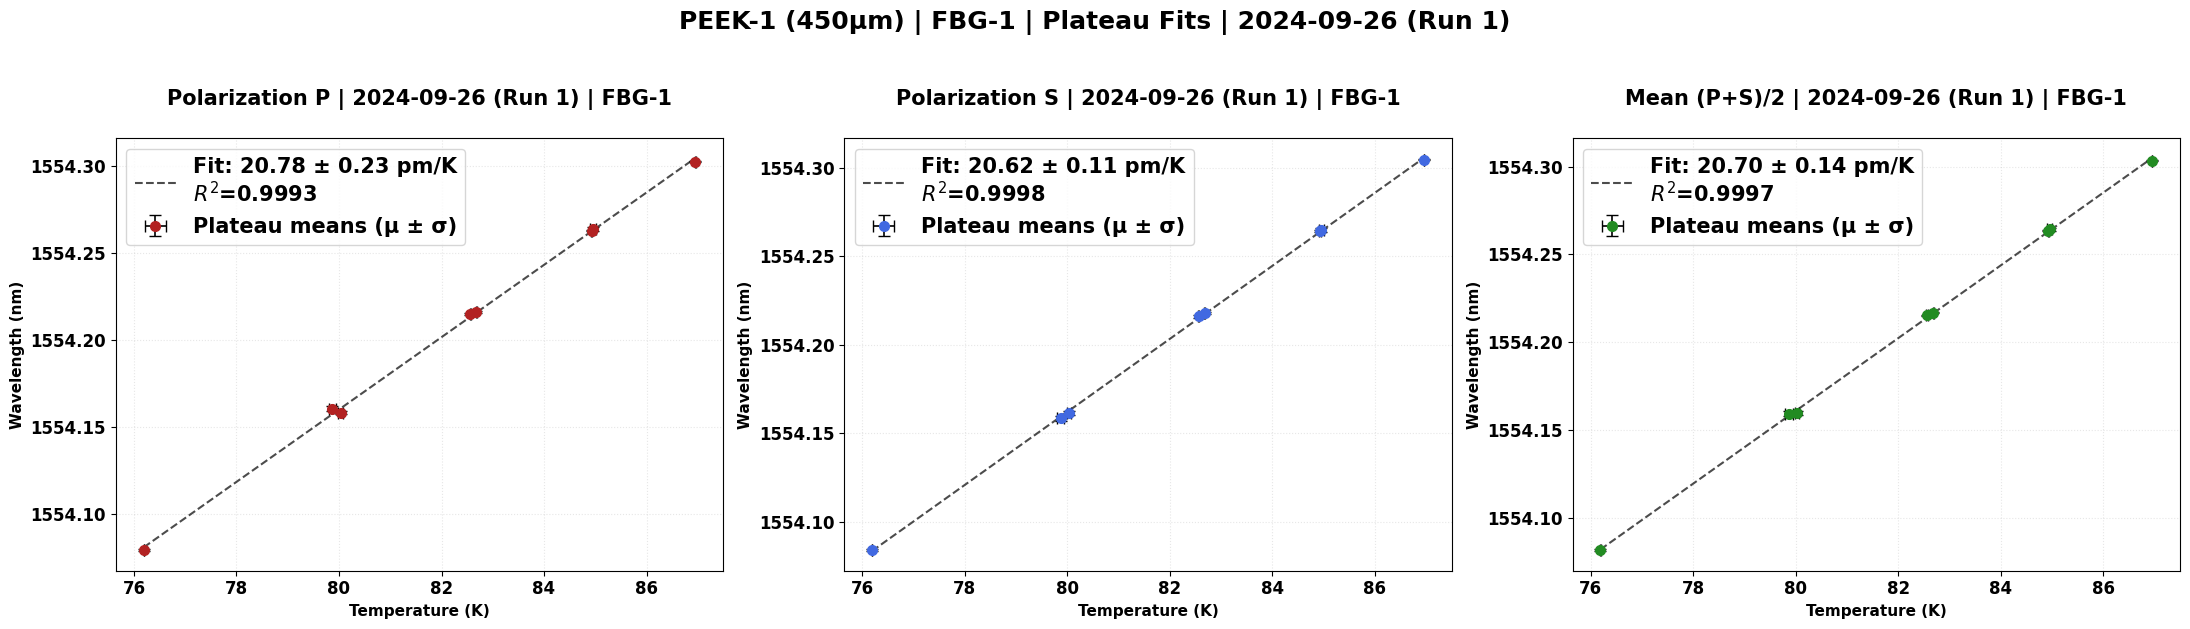

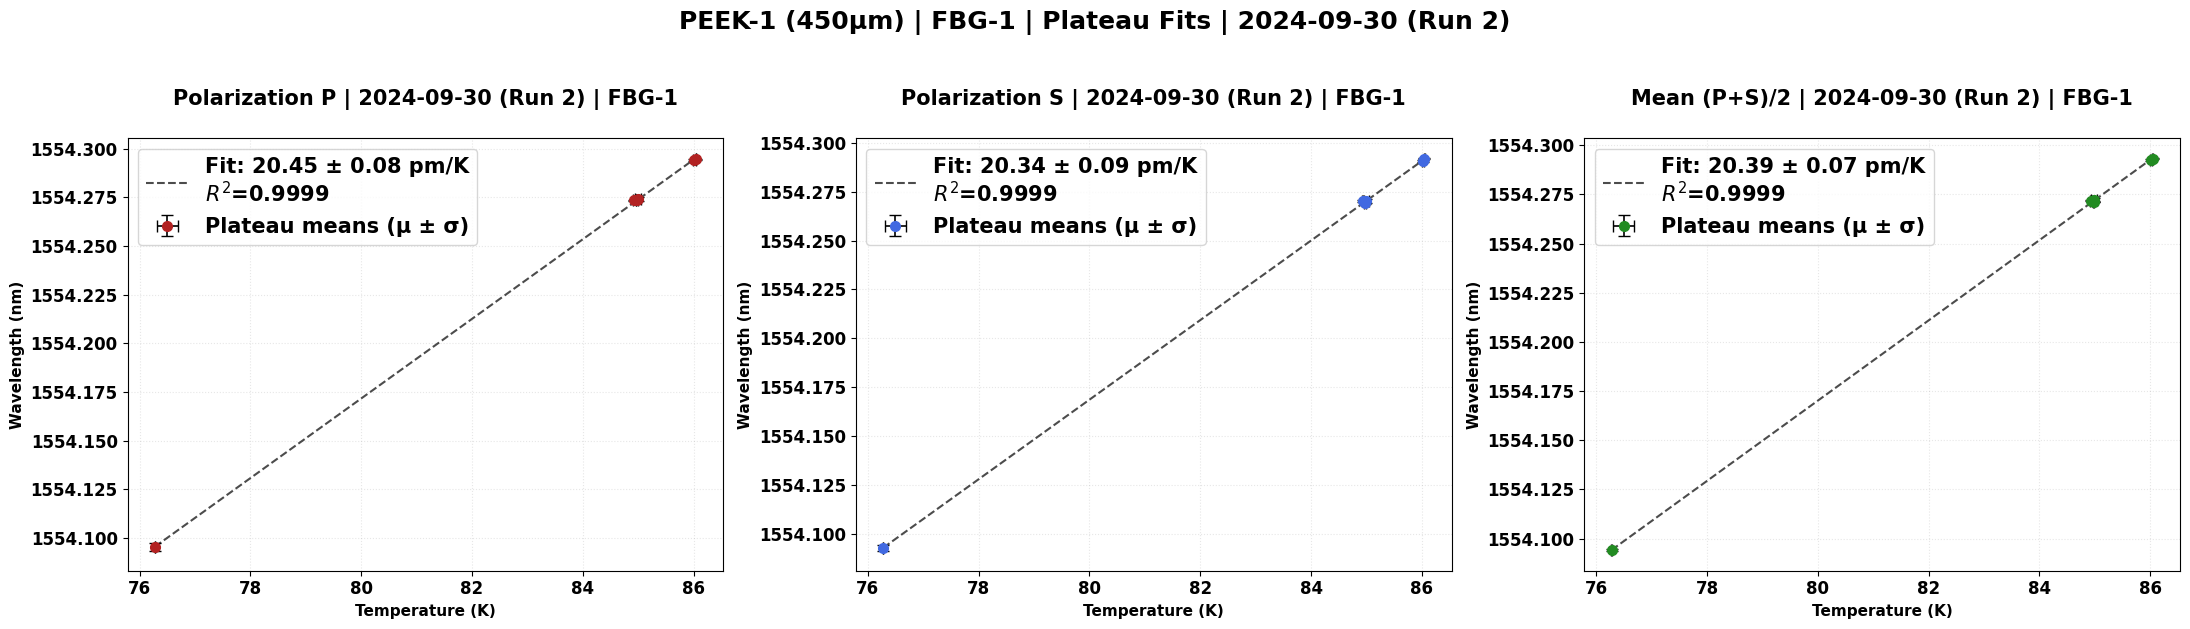

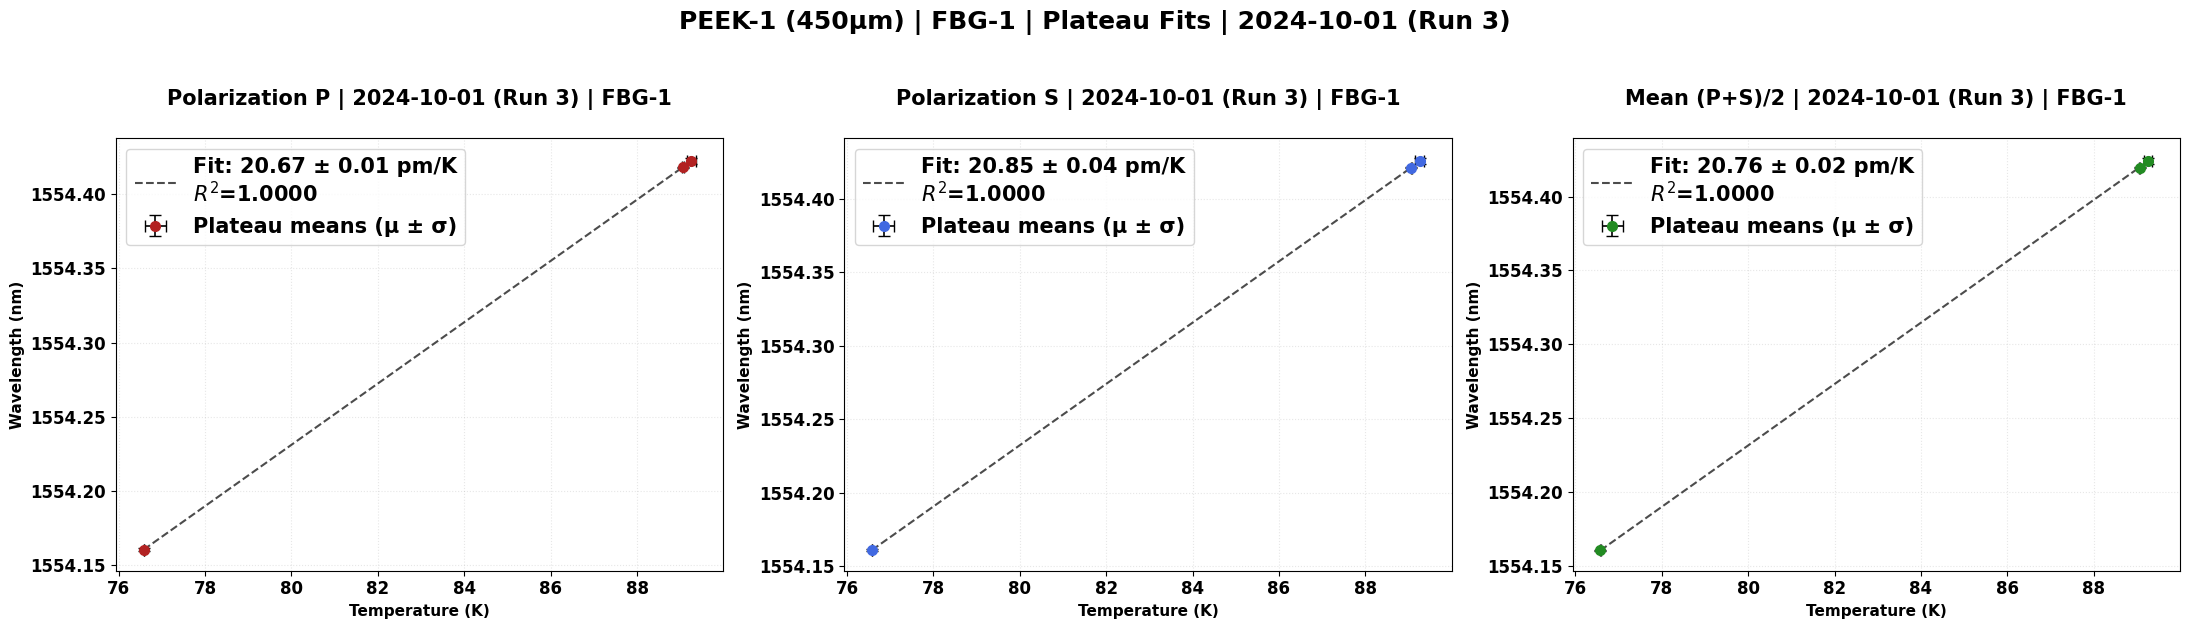


✅ Summary table of sensitivities (pm/K):


,Fecha,Run,Sensor,Slope_pm_per_K_P,Slope_pm_per_K_S,Slope_pm_per_K_Mean,Error_pm_per_K_P,Error_pm_per_K_S,Error_pm_per_K_Mean,R2_P,R2_S,R2_Mean,N_plateaus_P,N_plateaus_S,N_plateaus_Mean
0,2024-09-26,1,FBG-1,20.781375,20.624380,20.702878,0.226577,0.106685,0.141821,0.999287,0.999839,0.999719,8,8,8
1,2024-09-30,2,FBG-1,20.448632,20.337086,20.392859,0.084258,0.089027,0.072549,0.999932,0.999923,0.999949,6,6,6
2,2024-10-01,3,FBG-1,20.665277,20.850898,20.758088,0.009943,0.036320,0.023132,1.000000,0.999997,0.999999,3,3,3



Resumen corto:
2024-09-26 | Run 1 | FBG-1 | P 20.78 ± 0.23 | S 20.62 ± 0.11 | Mean 20.70 ± 0.14
2024-09-30 | Run 2 | FBG-1 | P 20.45 ± 0.08 | S 20.34 ± 0.09 | Mean 20.39 ± 0.07
2024-10-01 | Run 3 | FBG-1 | P 20.67 ± 0.01 | S 20.85 ± 0.04 | Mean 20.76 ± 0.02

Nota: cada punto del fit sale de la media dentro de cada plateau; si un plateau no tiene datos válidos tras filtrar, ese punto no entra.


In [28]:
# ============================================================================
# FITS 1x3 (P, S, Mean) per date and sensor + summary table (English titles + Run labels)
# Supports multiple dates and multiple detected sensors
# ============================================================================

from scipy import stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



def media_y_error(x):
    x = np.array(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) == 0:
        return np.nan, np.nan
    if len(x) == 1:
        return float(x[0]), np.nan
    return float(np.mean(x)), float(np.std(x, ddof=1))



def construir_series_por_plateau(fecha, sensor_idx=0, pol='P', usar_mean=False):
    times_temp = np.array(datos[fecha]['times_temp'])
    temp_raw = np.array(datos[fecha]['temp_val'])
    temp_ref = temp_raw[:, 6] if (temp_raw.ndim == 2 and temp_raw.shape[1] > 6) else np.full(len(times_temp), np.nan)

    times_peak = np.array(datos[fecha]['times_peak'])
    if times_peak.ndim > 1:
        times_peak = times_peak[:, 0]

    wav_all = np.array(datos[fecha]['wav'])
    intervalos = plateaus[fecha].get('P', [])

    # Get wav for sensor/polarization requested
    if usar_mean:
        # Interpolate P and S and take mean
        if wav_all.ndim == 2:
            wav_p = wav_all[:, 0] if wav_all.shape[1] > 0 else np.full(len(times_peak), np.nan)
            wav_s = wav_all[:, 1] if wav_all.shape[1] > 1 else np.full(len(times_peak), np.nan)
        elif wav_all.ndim == 3:
            try:
                wav_p = wav_all[:, 0, sensor_idx]
                wav_s = wav_all[:, 1, sensor_idx]
            except Exception:
                wav_p = wav_all[:, sensor_idx, 0]
                wav_s = wav_all[:, sensor_idx, 1]
        else:
            wav_p = np.full(len(times_peak), np.nan)
            wav_s = np.full(len(times_peak), np.nan)

        mask_p = ~np.isnan(wav_p)
        mask_s = ~np.isnan(wav_s)
        if np.sum(mask_p) < 2 or np.sum(mask_s) < 2:
            wav_interp = np.full(len(times_temp), np.nan)
        else:
            wav_p_i = np.interp([t.timestamp() for t in times_temp], [t.timestamp() for t in times_peak[mask_p]], wav_p[mask_p], left=np.nan, right=np.nan)
            wav_s_i = np.interp([t.timestamp() for t in times_temp], [t.timestamp() for t in times_peak[mask_s]], wav_s[mask_s], left=np.nan, right=np.nan)
            wav_interp = (wav_p_i + wav_s_i) / 2.0
    else:
        # Specific polarization
        idx_pol = 0 if pol == 'P' else 1
        if wav_all.ndim == 2:
            wav = wav_all[:, idx_pol] if wav_all.shape[1] > idx_pol else np.full(len(times_peak), np.nan)
        elif wav_all.ndim == 3:
            try:
                wav = wav_all[:, idx_pol, sensor_idx]
            except Exception:
                wav = wav_all[:, sensor_idx, idx_pol]
        else:
            wav = np.full(len(times_peak), np.nan)

        mask_w = ~np.isnan(wav)
        if np.sum(mask_w) < 2:
            wav_interp = np.full(len(times_temp), np.nan)
        else:
            wav_interp = np.interp([t.timestamp() for t in times_temp], [t.timestamp() for t in times_peak[mask_w]], wav[mask_w], left=np.nan, right=np.nan)

    # Compute plateau means using plateaus[fecha]['P']
    temp_means, temp_stds, wav_means, wav_stds = [], [], [], []
    for (t0, tfin) in intervalos:
        mask_plateau = (times_temp >= t0) & (times_temp <= tfin)
        t_mean, t_std = media_y_error(temp_ref[mask_plateau])
        w_mean, w_std = media_y_error(wav_interp[mask_plateau])
        temp_means.append(t_mean)
        temp_stds.append(t_std)
        wav_means.append(w_mean)
        wav_stds.append(w_std)

    x = np.array(temp_means)
    xerr = np.array(temp_stds)
    y = np.array(wav_means)
    yerr = np.array(wav_stds)
    mask_valid = ~np.isnan(x) & ~np.isnan(y)

    return {
        'x_mean': x[mask_valid],
        'xerr_mean': xerr[mask_valid],
        'y_mean': y[mask_valid],
        'yerr_mean': yerr[mask_valid],
        'times_temp': times_temp,
        'temp_ref': temp_ref,
        'wav_interp': wav_interp,
        'intervalos': intervalos,
    }


summary_rows = []
fechas_fit = [f for f in sorted(datos.keys()) if f in plateaus]
if len(fechas_fit) == 0:
    print("⚠️ No dates with plateaus defined for fitting.")
else:
    for run_idx, fecha in enumerate(fechas_fit, start=1):
        # detect number of sensors
        wav_all = np.array(datos[fecha]['wav'])
        if wav_all.ndim == 3:
            if wav_all.shape[1] in (1,2):
                n_sensors = wav_all.shape[2]
            elif wav_all.shape[2] in (1,2):
                n_sensors = wav_all.shape[1]
            else:
                n_sensors = max(wav_all.shape[1], wav_all.shape[2])
        elif wav_all.ndim == 2:
            n_sensors = 1
        else:
            n_sensors = 1

        for sensor_idx in range(n_sensors):
            fig, axes = plt.subplots(1, 3, figsize=(22, 6), sharey=False)
            plot_cfg = [
                {'name': 'P', 'title': 'Polarization P', 'color': 'firebrick', 'use_mean': False},
                {'name': 'S', 'title': 'Polarization S', 'color': 'royalblue', 'use_mean': False},
                {'name': 'Mean', 'title': 'Mean (P+S)/2', 'color': 'forestgreen', 'use_mean': True},
            ]

            for i, cfg in enumerate(plot_cfg):
                ax = axes[i]
                series = construir_series_por_plateau(fecha, sensor_idx=sensor_idx, pol=cfg['name'], usar_mean=cfg['use_mean'])
                x = series['x_mean']
                xerr = series['xerr_mean']
                y = series['y_mean']
                yerr = series['yerr_mean']

                if len(x) < 2:
                    ax.set_title(f"{cfg['title']} - Not enough points", fontsize=13, pad=20)
                    ax.grid(True, alpha=0.3, linestyle=':')
                    continue

                slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
                slope_pm = slope * 1e3
                err_pm = std_err * 1e3
                r2 = r_val ** 2

                summary_rows.append({
                    'Fecha': fecha,
                    'Run': run_idx,
                    'Sensor': f'FBG-{sensor_idx+1}',
                    'Canal': cfg['name'],
                    'Slope_pm_per_K': slope_pm,
                    'Error_pm_per_K': err_pm,
                    'R2': r2,
                    'N_plateaus': len(x)
                })

                # Each plotted point is the mean value computed inside each manual plateau.
                # The error bars are the dispersion inside that plateau (std dev).
                ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', color=cfg['color'], ecolor='black', elinewidth=1.2, capsize=4, markersize=7, label='Plateau means (μ ± σ)')
                xfit = np.linspace(np.min(x), np.max(x), 100)
                yfit = slope * xfit + intercept
                ax.plot(xfit, yfit, '--', color='black', alpha=0.7, label=f"Fit: {slope_pm:.2f} ± {err_pm:.2f} pm/K\n$R^2$={r2:.4f}")

                ax.set_title(f"{cfg['title']} | {fecha} (Run {run_idx}) | FBG-{sensor_idx+1}", fontsize=15, fontweight='bold', pad=24)
                ax.set_xlabel('Temperature (K)', fontsize=11)
                ax.set_ylabel('Wavelength (nm)', fontsize=11)
                ax.grid(True, alpha=0.3, linestyle=':')
                ax.ticklabel_format(useOffset=False, axis='y')
                ax.legend(fontsize=15, loc='best')

            plt.suptitle(f'PEEK-1 (450µm) | FBG-{sensor_idx+1} | Plateau Fits | {fecha} (Run {run_idx})', fontsize=18, y=1.04, fontweight='bold')
            plt.tight_layout()
            plt.show()

    df_fit_summary = pd.DataFrame(summary_rows)
    if not df_fit_summary.empty:
        df_fit_summary = df_fit_summary.sort_values(['Fecha', 'Run', 'Sensor', 'Canal']).reset_index(drop=True)

        # Resumen ancho: una fila por fecha/run/sensor y columnas separadas por canal
        df_fit_wide = df_fit_summary.pivot_table(
            index=['Fecha', 'Run', 'Sensor'],
            columns='Canal',
            values=['Slope_pm_per_K', 'Error_pm_per_K', 'R2', 'N_plateaus'],
            aggfunc='first'
        )
        df_fit_wide.columns = [f"{metric}_{canal}" for metric, canal in df_fit_wide.columns]
        df_fit_wide = df_fit_wide.reset_index()

        # Ordenar columnas principales y dejar slope separada por polarización y luego media
        desired_column_order = [
            'Fecha', 'Run', 'Sensor',
            'Slope_pm_per_K_P', 'Slope_pm_per_K_S', 'Slope_pm_per_K_Mean',
            'Error_pm_per_K_P', 'Error_pm_per_K_S', 'Error_pm_per_K_Mean',
            'R2_P', 'R2_S', 'R2_Mean',
            'N_plateaus_P', 'N_plateaus_S', 'N_plateaus_Mean'
        ]
        existing_columns = [column for column in desired_column_order if column in df_fit_wide.columns]
        remaining_columns = [column for column in df_fit_wide.columns if column not in existing_columns]
        df_fit_wide = df_fit_wide[existing_columns + remaining_columns]
    else:
        df_fit_wide = pd.DataFrame()

    print("\n✅ Summary table of sensitivities (pm/K):")
    display(df_fit_wide)

    def _fmt_pm(value, error, ndigits=2):
        if pd.isna(value):
            return "nan"
        if pd.isna(error):
            return f"{value:.{ndigits}f} ± nan"
        return f"{value:.{ndigits}f} ± {error:.{ndigits}f}"

    print("\nResumen corto:")
    for _, row in df_fit_wide.iterrows():
        print(
            f"{row['Fecha']} | Run {row['Run']} | {row['Sensor']} | "
            f"P {_fmt_pm(row.get('Slope_pm_per_K_P'), row.get('Error_pm_per_K_P'))} | "
            f"S {_fmt_pm(row.get('Slope_pm_per_K_S'), row.get('Error_pm_per_K_S'))} | "
            f"Mean {_fmt_pm(row.get('Slope_pm_per_K_Mean'), row.get('Error_pm_per_K_Mean'))}"
        )

    print("\nNota: cada punto del fit sale de la media dentro de cada plateau; si un plateau no tiene datos válidos tras filtrar, ese punto no entra.")


=== Diagnostic spectra for 2024-09-26 (Run 1) ===
  -> idx=151 | cand=2024-09-26 11:19:00 | event_ts=2024-09-26 09:14:00.250124
  -> wav_data.shape=(2, 3, 39200)
  -> idx=151 | cand=2024-09-26 11:25:30 | event_ts=2024-09-26 09:14:00.250124
  -> wav_data.shape=(2, 3, 39200)
  -> idx=151 | cand=2024-09-26 11:32:00 | event_ts=2024-09-26 09:14:00.250124
  -> wav_data.shape=(2, 3, 39200)
  -> idx=151 | cand=2024-09-26 11:31:59.995110 | event_ts=2024-09-26 09:14:00.250124
  -> wav_data.shape=(2, 3, 39200)


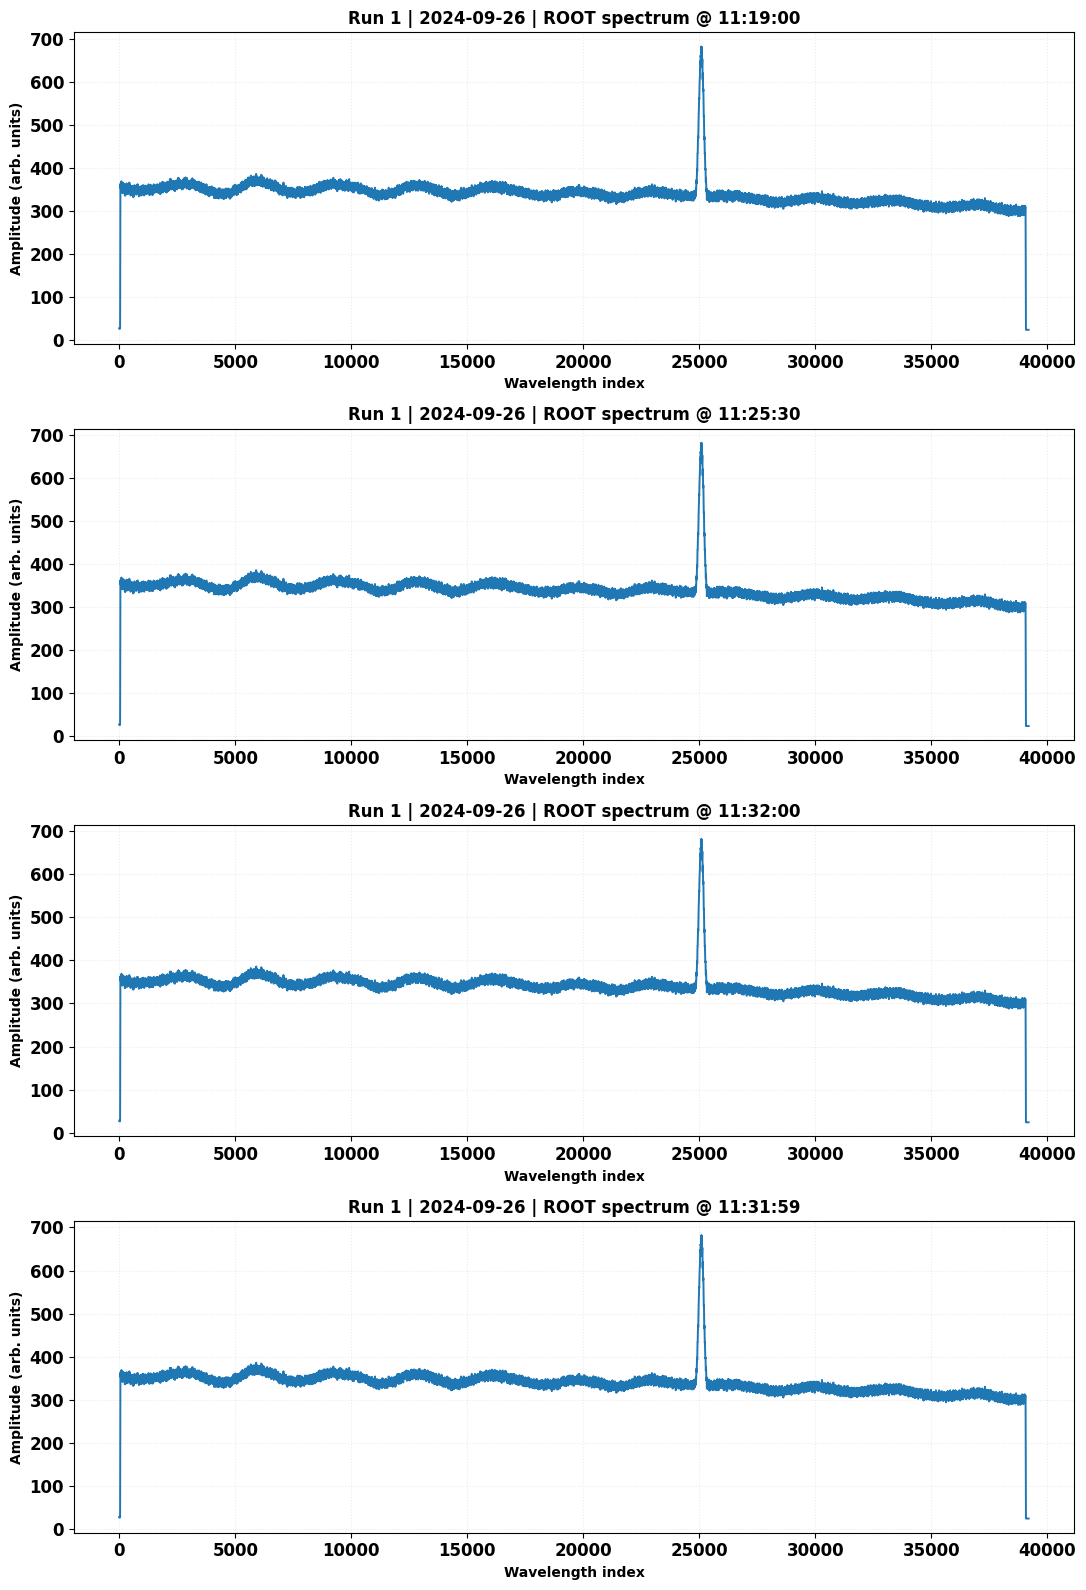


=== Diagnostic spectra for 2024-09-30 (Run 2) ===
  -> idx=3915 | cand=2024-09-30 11:09:00 | event_ts=2024-09-30 11:09:00.370432
  -> wav_data.shape=(2, 3, 39200)
  -> idx=3960 | cand=2024-09-30 11:10:30 | event_ts=2024-09-30 11:10:30.011675
  -> wav_data.shape=(2, 3, 39200)
  -> idx=4005 | cand=2024-09-30 11:12:00 | event_ts=2024-09-30 11:11:59.652894
  -> wav_data.shape=(2, 3, 39200)
  -> idx=4005 | cand=2024-09-30 11:11:59.996192 | event_ts=2024-09-30 11:11:59.652894
  -> wav_data.shape=(2, 3, 39200)


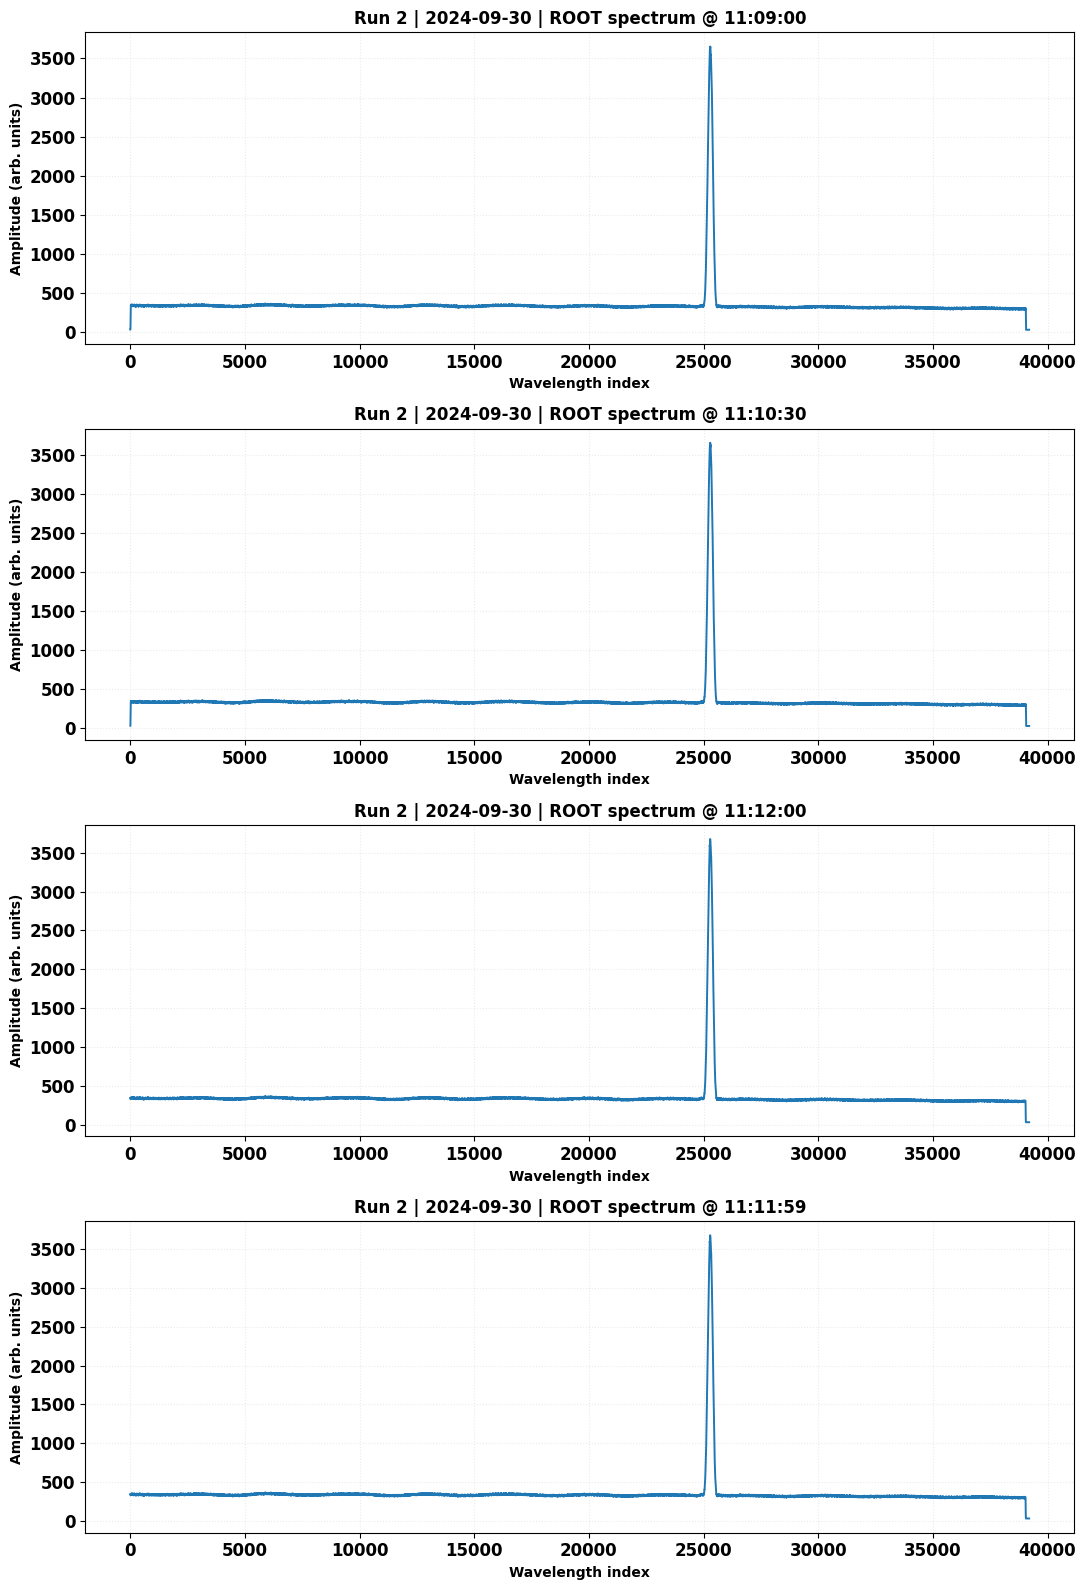


=== Diagnostic spectra for 2024-10-01 (Run 3) ===
  -> idx=3974 | cand=2024-10-01 09:11:00 | event_ts=2024-10-01 09:10:59.940758
  -> wav_data.shape=(2, 3, 39200)
  -> idx=4064 | cand=2024-10-01 09:14:00 | event_ts=2024-10-01 09:13:59.223524
  -> wav_data.shape=(2, 3, 39200)
  -> idx=4155 | cand=2024-10-01 09:17:00 | event_ts=2024-10-01 09:17:00.497831
  -> wav_data.shape=(2, 3, 39200)
  -> idx=4064 | cand=2024-10-01 09:13:59.996518 | event_ts=2024-10-01 09:13:59.223524
  -> wav_data.shape=(2, 3, 39200)


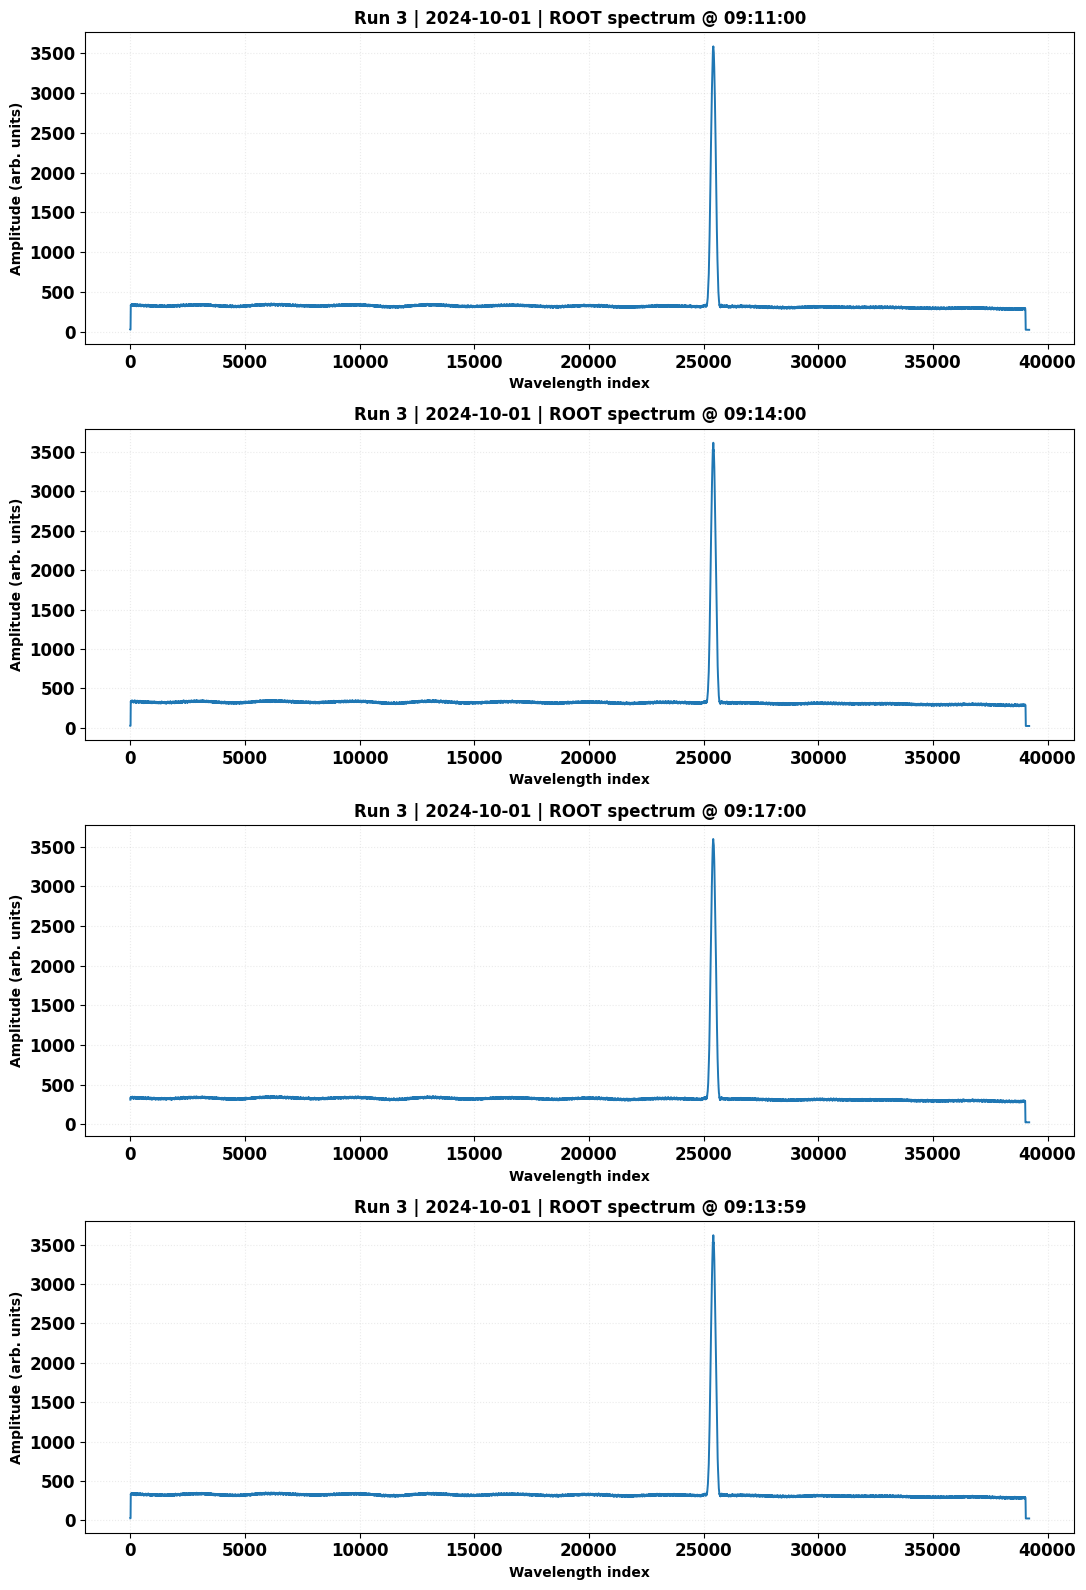


✅ Diagnostic per-day spectrum checks completed.


In [29]:
# ============================================================================
# Per-day Spectrum Diagnostic Plot — try multiple candidate times inside plateaus
# Will attempt to extract full spectrum from ROOT 'spectrum' tree; otherwise
# falls back to inspecting peak-derived values around candidate times.
# ============================================================================

import matplotlib.pyplot as plt
import numpy as np
import datetime

fechas_plot = [f for f in sorted(datos.keys()) if f in plateaus]
if len(fechas_plot) == 0:
    print('⚠️ No dates with plateaus found for spectrum plotting.')
else:
    try:
        import uproot
    except Exception:
        uproot = None

    for run_idx, fecha in enumerate(fechas_plot, start=1):
        print(f"\n=== Diagnostic spectra for {fecha} (Run {run_idx}) ===")

        wav_all = np.array(datos[fecha]['wav'])
        times_peak = np.array(datos[fecha]['times_peak'])
        if times_peak.ndim > 1:
            times_peak = times_peak[:, 0]
        times_temp = np.array(datos[fecha]['times_temp'])

        intervalos = plateaus[fecha].get('P', []) if fecha in plateaus else []
        candidate_times = []

        # Build candidate times: start/mid/end of first plateau, plus median peak time
        if len(intervalos) > 0:
            t0, tfin = intervalos[0]
            candidate_times.extend([t0, t0 + (tfin - t0) / 2, tfin])
            # add first/median/last peak inside plateau if available
            mask_plateau = (times_peak >= t0) & (times_peak <= tfin)
            idxs = np.where(mask_plateau)[0]
            if idxs.size > 0:
                candidate_times.append(times_peak[idxs[0]])
                candidate_times.append(times_peak[idxs[len(idxs)//2]])
                candidate_times.append(times_peak[idxs[-1]])

        # add global median peak time as fallback — compute median on timestamps to avoid datetime addition
        if times_peak.size > 0:
            try:
                ts_list = [float(t.timestamp()) for t in times_peak]
                median_ts = float(np.median(ts_list))
                candidate_times.append(datetime.datetime.fromtimestamp(median_ts))
            except Exception:
                # last resort: try to coerce via numpy (may fail for datetimes)
                try:
                    candidate_times.append(np.median(times_peak))
                except Exception:
                    pass

        # unique and limit to max_plots
        # convert to datetime if needed
        def to_dt(t):
            if isinstance(t, (np.datetime64,)):
                return datetime.datetime.fromtimestamp(t.astype('datetime64[s]').astype('int'))
            if isinstance(t, (float, int)):
                return datetime.datetime.fromtimestamp(float(t))
            return t

        candidate_times_dt = []
        for t in candidate_times:
            try:
                candidate_times_dt.append(to_dt(t))
            except Exception:
                pass
        # deduplicate by timestamp
        seen = set()
        candidate_filtered = []
        for t in candidate_times_dt:
            key = int(t.timestamp())
            if key not in seen:
                seen.add(key)
                candidate_filtered.append(t)
        candidate_filtered = candidate_filtered[:4]

        # Attempt to open ROOT file if available to extract full spectrum
        filepath = None
        if 'archivos' in globals() and fecha in archivos:
            filepath = archivos[fecha]
        elif 'ruta' in globals():
            filepath = ruta

        spectrum_loaded = False
        wav_data_root = None
        tree = None
        if uproot is not None and filepath is not None:
            try:
                f = uproot.open(filepath)
                if 'spectrum' in f:
                    tree = f['spectrum']
            except Exception:
                tree = None

        n_plots = max(1, len(candidate_filtered))
        fig, axs = plt.subplots(n_plots, 1, figsize=(11, 4 * n_plots))
        if n_plots == 1:
            axs = [axs]

        for ax, cand_time in zip(axs, candidate_filtered):
            # Try ROOT spectrum first
            plotted = False
            if tree is not None:
                try:
                    # try to locate closest entry by timestamp
                    try:
                        t_arr = tree['t'].array(library='np')
                        if t_arr.ndim > 1:
                            t_vals = t_arr[:,0]
                        else:
                            t_vals = t_arr
                        # convert cand_time to timestamp
                        ts = cand_time.timestamp()
                        idx = int(np.argmin(np.abs(t_vals - ts)))
                        print(f"  -> idx={idx} | cand={cand_time} | event_ts={datetime.datetime.fromtimestamp(float(t_vals[idx]))}")
                    except Exception:
                        idx = 0

                    wav_raw = tree['wav'].array(library='np', entry_start=idx, entry_stop=idx+1)
                    if wav_raw.size > 0:
                        wav_entry = wav_raw[0]
                        print(f"  -> wav_data.shape={np.shape(wav_entry)}")
                        # choose a single 1D trace: P polarization, first sensor by default
                        if hasattr(wav_entry, 'shape'):
                            if wav_entry.ndim == 1:
                                y = wav_entry
                            elif wav_entry.ndim == 2:
                                y = wav_entry[0]
                            elif wav_entry.ndim == 3:
                                if wav_entry.shape[0] == 2:
                                    y = wav_entry[0, 0, :]
                                elif wav_entry.shape[1] == 2:
                                    y = wav_entry[0, 0, :]
                                else:
                                    y = wav_entry[0, 0, :]
                            else:
                                y = np.ravel(wav_entry)
                        else:
                            y = np.ravel(wav_entry)
                        x = np.arange(len(y))

                        ax.plot(x, y, linewidth=1.4, color='#1f77b4')
                        ax.set_title(f'Run {run_idx} | {fecha} | ROOT spectrum @ {cand_time.strftime("%H:%M:%S")}', fontsize=12, fontweight='bold')
                        ax.set_xlabel('Wavelength index')
                        ax.set_ylabel('Amplitude (arb. units)')
                        ax.grid(alpha=0.25, linestyle=':')
                        plotted = True
                except Exception:
                    plotted = False

            if not plotted:
                # Fallback: inspect peak-derived wav values near cand_time
                # find nearest times_peak index
                if times_peak.size == 0:
                    ax.text(0.5, 0.5, 'No peak timestamps available', ha='center', va='center')
                else:
                    # convert candidate time to timestamp and find nearest index
                    ts = cand_time.timestamp()
                    diffs = np.abs(np.array([t.timestamp() for t in times_peak]) - ts)
                    idx_near = int(np.argmin(diffs))

                    # Collect a few peak entries around idx_near for diagnostic
                    idx_start = max(0, idx_near - 3)
                    idx_end = min(len(times_peak), idx_near + 4)
                    if wav_all.ndim == 2:
                        wav_p = wav_all[:,0] if wav_all.shape[1] > 0 else np.full(len(times_peak), np.nan)
                        y = wav_p[idx_start:idx_end]
                    elif wav_all.ndim == 3:
                        try:
                            if wav_all.shape[0] == 2:
                                wav_p = wav_all[0, 0, :]
                            else:
                                wav_p = wav_all[0, 0, :]
                        except Exception:
                            wav_p = wav_all[0, 0, :] if wav_all.ndim == 3 else np.full(len(times_peak), np.nan)
                        y = wav_p[idx_start:idx_end]
                    else:
                        y = np.full(min(7, len(times_peak)), np.nan)

                    x = np.arange(idx_start, idx_end)
                    ax.plot(x, y, marker='o', linestyle='-', color='#ff7f0e')
                    ax.set_title(f'Run {run_idx} | {fecha} | Peak-values around {cand_time.strftime("%H:%M:%S")} (idx ~ {idx_near})', fontsize=12, fontweight='bold')
                    ax.set_xlabel('Peak index')
                    ax.set_ylabel('Peak wavelength (nm)')
                    ax.grid(alpha=0.25, linestyle=':')

        plt.tight_layout()
        plt.show()

    print('\n✅ Diagnostic per-day spectrum checks completed.')

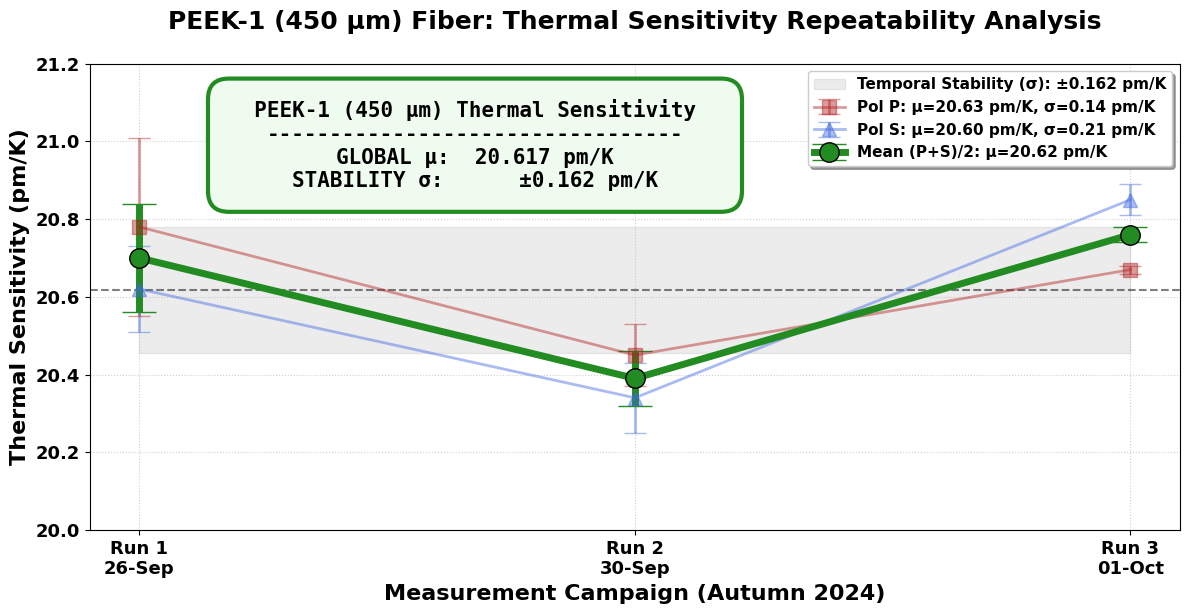

PEEK-1 Final Statistics (3 Runs):
Global Mean: 20.6167 pm/K
Global Sigma: 0.1621 pm/K


In [8]:
# ============================================================================
# PEEK-1 (450 μm) REPEATABILITY ANALYSIS: POLARIZATION & MEAN
# Features: Updated Run 3, Global KPI Box, and High Visibility for Slides
# ============================================================================
import matplotlib.pyplot as plt
import numpy as np

# 1. SETUP DE DATOS (Actualizados con Run 3 corregido)
runs = ['Run 1\n26-Sep', 'Run 2\n30-Sep', 'Run 3\n01-Oct']
x = np.arange(len(runs))

# v: valor (pm/K), e: incertidumbre del ajuste (pm/K)
data_p = {"v": [20.78, 20.45, 20.67], "e": [0.23, 0.08, 0.01]}
data_s = {"v": [20.62, 20.34, 20.85], "e": [0.11, 0.09, 0.04]}
data_m = {"v": [20.70, 20.39, 20.76], "e": [0.14, 0.07, 0.02]}

# Estadísticas globales (basadas en la serie Mean)
means = np.array(data_m["v"])
sigma_p = np.std(np.array(data_p["v"]))
sigma_s = np.std(np.array(data_s["v"]))
global_mu = np.mean(means)
global_sigma = np.std(means)

# 2. CONFIGURACIÓN DE FIGURA
plt.rcParams.update({'font.weight': 'bold', 'axes.labelweight': 'bold'})
plt.figure(figsize=(12, 8))

# Sombreado de estabilidad temporal (Sigma global de la red)
plt.axhline(global_mu, color='black', linestyle='--', linewidth=1.5, alpha=0.5)
plt.fill_between(x, global_mu - global_sigma, global_mu + global_sigma,
                 color='gray', alpha=0.15, label=f'Temporal Stability (σ): ±{global_sigma:.3f} pm/K')

# 3. PLOT DE SERIES (Polarizaciones y Media)
# Polarización P
plt.errorbar(x, data_p["v"], yerr=data_p["e"], fmt='s-', color='firebrick',
             capsize=8, markersize=10, linewidth=2, alpha=0.45, 
             label=f'Pol P: μ={np.mean(data_p["v"]):.2f} pm/K, σ={sigma_p:.2f} pm/K')

# Polarización S
plt.errorbar(x, data_s["v"], yerr=data_s["e"], fmt='^-', color='royalblue',
             capsize=8, markersize=10, linewidth=2, alpha=0.45, 
             label=f'Pol S: μ={np.mean(data_s["v"]):.2f} pm/K, σ={sigma_s:.2f} pm/K')

# Media P+S (Serie principal destacada)
plt.errorbar(x, data_m["v"], yerr=data_m["e"], fmt='o-', color='forestgreen',
             capsize=12, markersize=14, linewidth=5, markeredgecolor='black',
             label=f'Mean (P+S)/2: μ={global_mu:.2f} pm/K')

# 4. CUADRO DE TEXTO (KPI VERDICT)
kpi_text = (
    f"  PEEK-1 (450 μm) Thermal Sensitivity  \n"
    f"---------------------------------\n"
    f"GLOBAL μ:  {global_mu:.3f} pm/K\n"
    f"STABILITY σ:      ±{global_sigma:.3f} pm/K"
)

# Posicionado centrado en la parte inferior para no tapar los datos
plt.text(0.4, 0.76, kpi_text, transform=plt.gcf().transFigure, fontsize=15, 
         fontweight='bold', fontfamily='monospace', ha='center',
         bbox=dict(boxstyle='round,pad=1', facecolor='#F0FBF0', edgecolor='forestgreen', linewidth=3))

# 5. ESTILO DE EJES Y TÍTULOS
plt.title('PEEK-1 (450 μm) Fiber: Thermal Sensitivity Repeatability Analysis', fontsize=18, pad=25, fontweight='bold')
plt.ylabel('Thermal Sensitivity (pm/K)', fontsize=16)
plt.xlabel('Measurement Campaign (Autumn 2024)', fontsize=16)
plt.xticks(x, runs, fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(20.0, 21.2) # Rango optimizado para observar la dispersión

# Leyenda profesional
leg = plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.setp(leg.get_texts(), fontweight='bold')

plt.tight_layout(rect=[0, 0.22, 1, 1]) # Ajuste para dejar espacio al KPI box
plt.show()

print(f"PEEK-1 Final Statistics (3 Runs):\nGlobal Mean: {global_mu:.4f} pm/K\nGlobal Sigma: {global_sigma:.4f} pm/K")